# Laboratorio 03 — Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)


---
## Actividad 1 — Descarga y carga del conjunto de datos

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Semilla global para reproducibilidad (Actividad 6)
SEED = 42
np.random.seed(SEED)

print('Librerías importadas ')

Librerías importadas 


Los archivos descargados de Kaggle son:
- `train.csv` — dataset principal con variable respuesta `SalePrice` (1,460 registros)
- `test.csv` — dataset sin variable respuesta, usado para submissions en Kaggle
- `data_description.txt` — diccionario de variables
- `sample_submission.csv` — formato de entrega para Kaggle

Para este laboratorio se trabaja únicamente con `train.csv`, ya que es el único archivo que contiene `SalePrice`.

In [7]:
df = pd.read_csv('./data/train.csv')

print(f'Dataset cargado ')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado 
Dimensiones: 1460 filas × 81 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Actividad 2 — Análisis exploratorio de los datos

### 2.1 Preguntas de investigación

Para guiar el análisis exploratorio, se plantean las siguientes preguntas:

1. ¿Cómo se distribuye el precio de las viviendas? ¿Es simétrica la distribución?
2. ¿Qué variables numéricas tienen mayor correlación con `SalePrice`?
3. ¿Influye la calidad general (`OverallQual`) en el precio de manera significativa?
4. ¿El tamaño de la vivienda (`GrLivArea`) es el mejor predictor simple del precio?
5. ¿Existen outliers que puedan afectar los modelos?
6. ¿El vecindario (`Neighborhood`) explica diferencias de precio?
7. ¿Hay variables con alta proporción de nulos que deban ser tratadas con cuidado?

### 2.2 Estructura general del dataset

In [224]:
# Tipos de datos
print('Tipos de datos:')
print(df.dtypes.value_counts())

# Separar columnas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numéricas: {len(num_cols)}')
print(f'Variables categóricas: {len(cat_cols)}')

Tipos de datos:
object     43
int64      35
float64     3
Name: count, dtype: int64

Variables numéricas: 38
Variables categóricas: 43


**Hallazgo:** El dataset tiene 81 variables: 38 numéricas y 43 categóricas. Entre las numéricas se encuentran tanto variables continuas (áreas en pies cuadrados) como ordinales codificadas como enteros (calificaciones de 1 a 10). Las categóricas representan atributos cualitativos como tipo de zona, material del tejado o estilo de la vivienda.

### 2.3 Estadísticas descriptivas

In [225]:
# Variables numéricas
df[num_cols].describe().T.sort_values('std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.00,180921.20,79442.50,34900.00,129975.00,163000.00,214000.00,755000.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
GrLivArea,1460.00,1515.46,525.48,334.00,1129.50,1464.00,1776.75,5642.00
MiscVal,1460.00,43.49,496.12,0.00,0.00,0.00,0.00,15500.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00
BsmtUnfSF,1460.00,567.24,441.87,0.00,223.00,477.50,808.00,2336.00
TotalBsmtSF,1460.00,1057.43,438.71,0.00,795.75,991.50,1298.25,6110.00
2ndFlrSF,1460.00,346.99,436.53,0.00,0.00,0.00,728.00,2065.00
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00
1stFlrSF,1460.00,1162.63,386.59,334.00,882.00,1087.00,1391.25,4692.00


In [226]:
# Variables categóricas
df[cat_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


**Hallazgo:** Hay variables numéricas con alta desviación estándar como `SalePrice`, `GrLivArea` y `LotArea`, lo que indica propiedades muy diversas. Algunos mínimos en 0 (como `MasVnrArea`, `BsmtFinSF1`) reflejan que no todas las casas tienen esa característica. Entre las categóricas, `Street` es casi siempre 'Pave' y podría aportar poco al modelo.

### 2.4 Análisis de valores nulos

In [227]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(f'Variables con valores nulos: {len(nulos_df)}')
nulos_df

Variables con valores nulos: 19


,Nulos,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\683793669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')


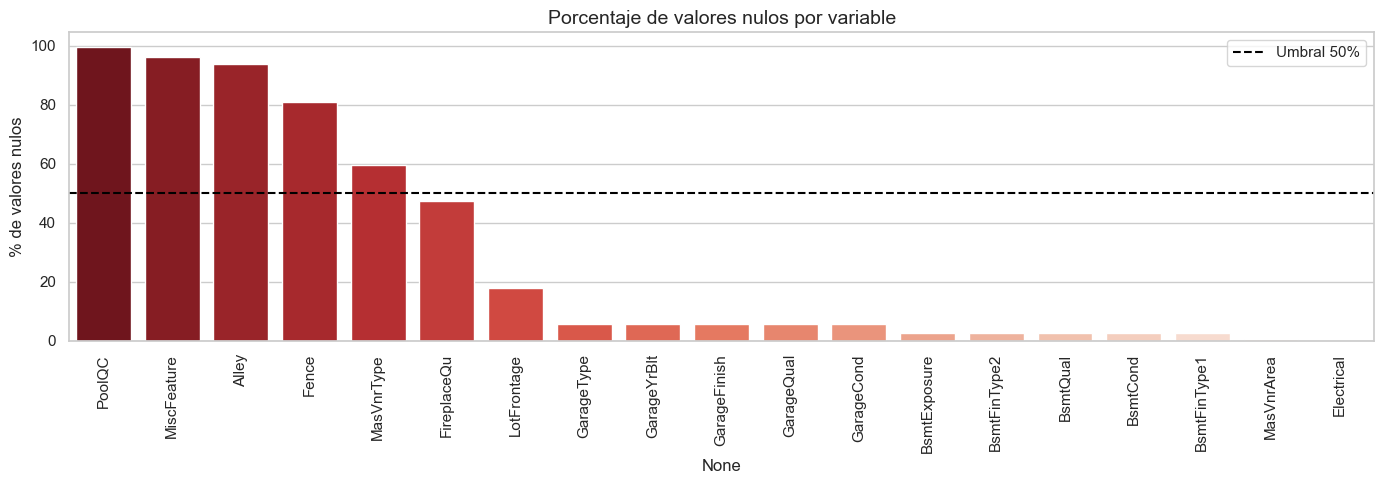

In [228]:
plt.figure(figsize=(14, 5))
sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')
plt.xticks(rotation=90)
plt.axhline(y=50, color='black', linestyle='--', label='Umbral 50%')
plt.title('Porcentaje de valores nulos por variable', fontsize=14)
plt.ylabel('% de valores nulos')
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** Variables como `PoolQC`, `MiscFeature`, `Alley` y `Fence` superan el 80% de nulos. Según `data_description.txt`, en estos casos NA no es un dato faltante sino que indica *ausencia de la característica* (sin piscina, sin callejón, etc.). Por eso se imputarán con `'None'` y no se eliminarán. Las variables numéricas relacionadas (áreas de garaje, sótano) también usan NA como ausencia y se imputarán con 0.

### 2.5 Preprocesamiento

In [8]:
# NA semántico en categóricas → 'None'
cat_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_none:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# NA semántico en numéricas → 0
num_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage → mediana por vecindario (captura variación geográfica mejor que la mediana global)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical → moda (solo 1 nulo)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Eliminar Id (no tiene valor predictivo)
df = df.drop(columns=['Id'])

print(f'Valores nulos restantes: {df.isnull().sum().sum()}')
print(f'Dimensiones finales: {df.shape}')

Valores nulos restantes: 0
Dimensiones finales: (1460, 80)


### 2.6 Análisis de la variable respuesta: SalePrice

In [230]:
print('Estadísticas de SalePrice:')
print(df['SalePrice'].describe())
print(f'\nAsimetría (skewness): {df["SalePrice"].skew():.4f}')
print(f'Curtosis (kurtosis):  {df["SalePrice"].kurt():.4f}')

Estadísticas de SalePrice:
count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

Asimetría (skewness): 1.8829
Curtosis (kurtosis):  6.5363


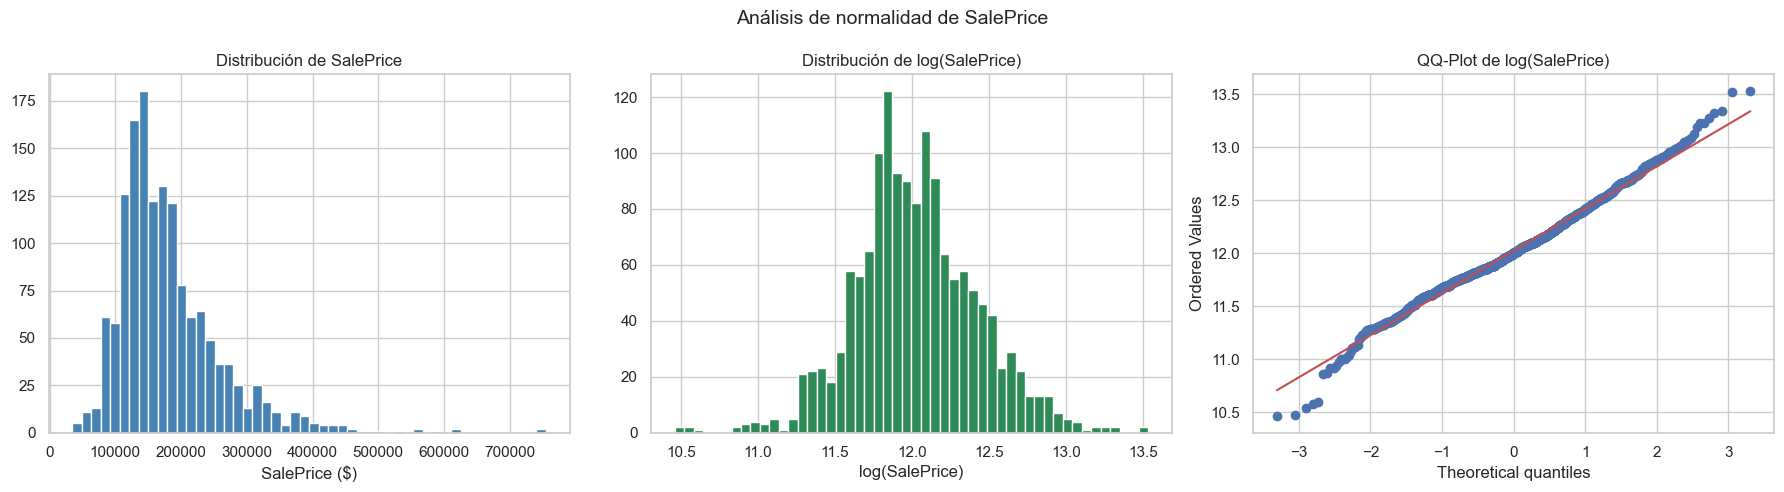

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

saleprice_norm_preview = StandardScaler().fit_transform(df[['SalePrice']]).ravel()

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice ($)')

axes[1].hist(saleprice_norm_preview, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de SalePrice normalizado')
axes[1].set_xlabel('SalePrice (z-score)')

stats.probplot(saleprice_norm_preview, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot de SalePrice normalizado')

plt.suptitle('Análisis de SalePrice antes y después de normalización', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Normalización z-score de la variable respuesta
saleprice_scaler = StandardScaler()
df['SalePriceNorm'] = saleprice_scaler.fit_transform(df[['SalePrice']])

# Prueba de normalidad Shapiro-Wilk sobre variable normalizada (escala z-score)
muestra = df['SalePriceNorm'].sample(500, random_state=SEED)
stat, p = stats.shapiro(muestra)
print('Shapiro-Wilk sobre SalePrice normalizado:')
print(f'  W = {stat:.6f}, p-valor = {p:.6f}')
print('  → Se rechaza normalidad (p < 0.05)' if p < 0.05 else '  → No se rechaza normalidad')

print('\nSe usará SalePrice normalizado como variable respuesta en los modelos base.')
print(f'Media SalePriceNorm: {df["SalePriceNorm"].mean():.4f}')
print(f'Desv. estándar SalePriceNorm: {df["SalePriceNorm"].std():.4f}')
print('Justificación: escala estandarizada para estabilidad numérica y comparabilidad entre variables.')

Shapiro-Wilk sobre SalePrice normalizado:
  W = 0.829041, p-valor = 0.000000
  → Se rechaza normalidad (p < 0.05)

Se usará SalePrice normalizado como variable respuesta en los modelos base.
Media SalePriceNorm: 0.0000
Desv. estándar SalePriceNorm: 1.0003
Justificación: escala estandarizada para estabilidad numérica y comparabilidad entre variables.


### 2.7 Análisis de outliers

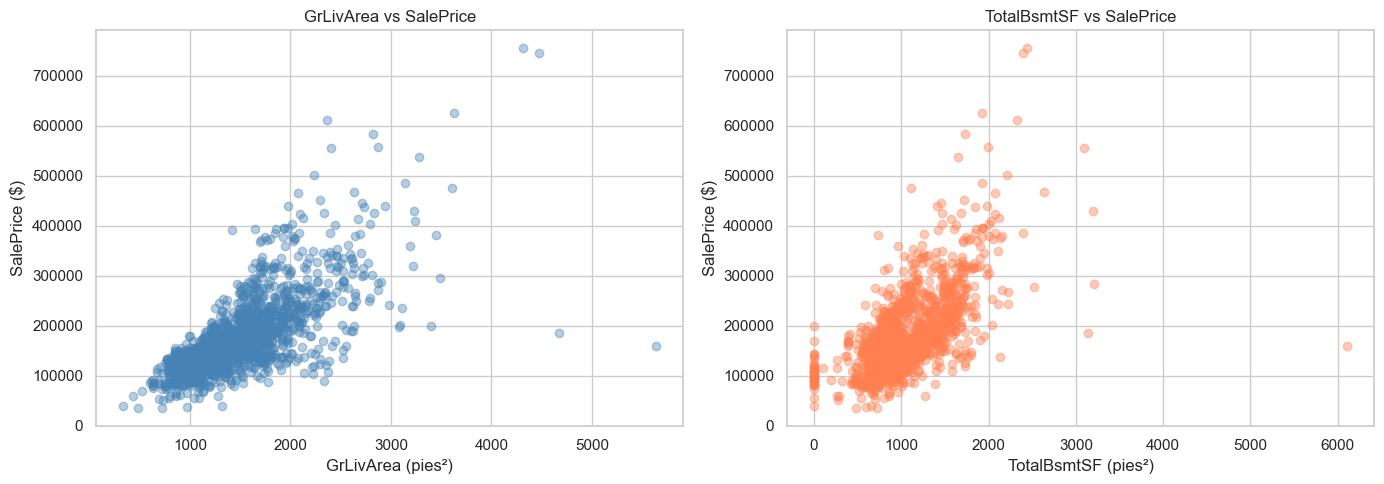

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
axes[0].set_title('GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea (pies²)')
axes[0].set_ylabel('SalePrice ($)')

# TotalBsmtSF vs SalePrice
axes[1].scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.4, color='coral')
axes[1].set_title('TotalBsmtSF vs SalePrice')
axes[1].set_xlabel('TotalBsmtSF (pies²)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.show()

In [10]:
# Identificar y eliminar outliers evidentes en GrLivArea
# Casas con GrLivArea > 4000 pero SalePrice bajo son anomalías documentadas en el dataset
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f'Outliers identificados en GrLivArea: {len(outliers)}')
print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

df = df.drop(outliers.index)
print(f'\nDataset sin outliers: {df.shape}')

Outliers identificados en GrLivArea: 2
      GrLivArea  SalePrice  OverallQual Neighborhood
523        4676     184750           10      Edwards
1298       5642     160000           10      Edwards

Dataset sin outliers: (1458, 81)


**Hallazgo:** Se identifican 2 propiedades con área habitable superior a 4,000 pies² pero con precios de venta inusualmente bajos (menores a $200,000). Estas observaciones son inconsistentes con el mercado y distorsionarían los modelos de regresión. Se eliminan del dataset de entrenamiento.

### 2.8 Análisis de correlación con SalePrice

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\1643988704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')


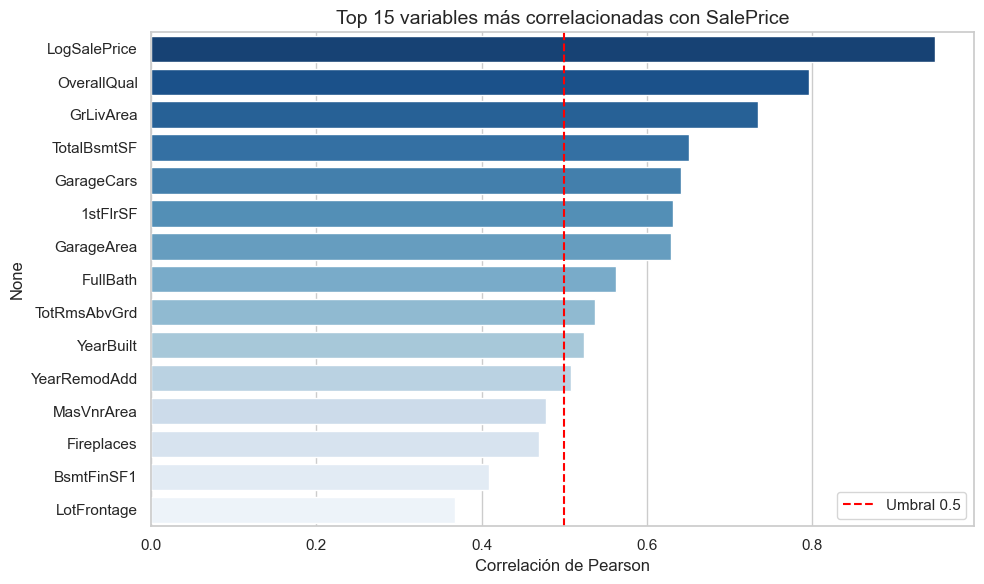

Top 15 correlaciones con SalePrice:
LogSalePrice   0.95
OverallQual    0.80
GrLivArea      0.73
TotalBsmtSF    0.65
GarageCars     0.64
1stFlrSF       0.63
GarageArea     0.63
FullBath       0.56
TotRmsAbvGrd   0.54
YearBuilt      0.52
YearRemodAdd   0.51
MasVnrArea     0.48
Fireplaces     0.47
BsmtFinSF1     0.41
LotFrontage    0.37
Name: SalePrice, dtype: float64


In [235]:
# Top 15 variables numéricas más correlacionadas con SalePrice
num_cols_updated = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[num_cols_updated].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

top15 = correlaciones.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')
plt.title('Top 15 variables más correlacionadas con SalePrice', fontsize=14)
plt.xlabel('Correlación de Pearson')
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 15 correlaciones con SalePrice:')
print(top15)

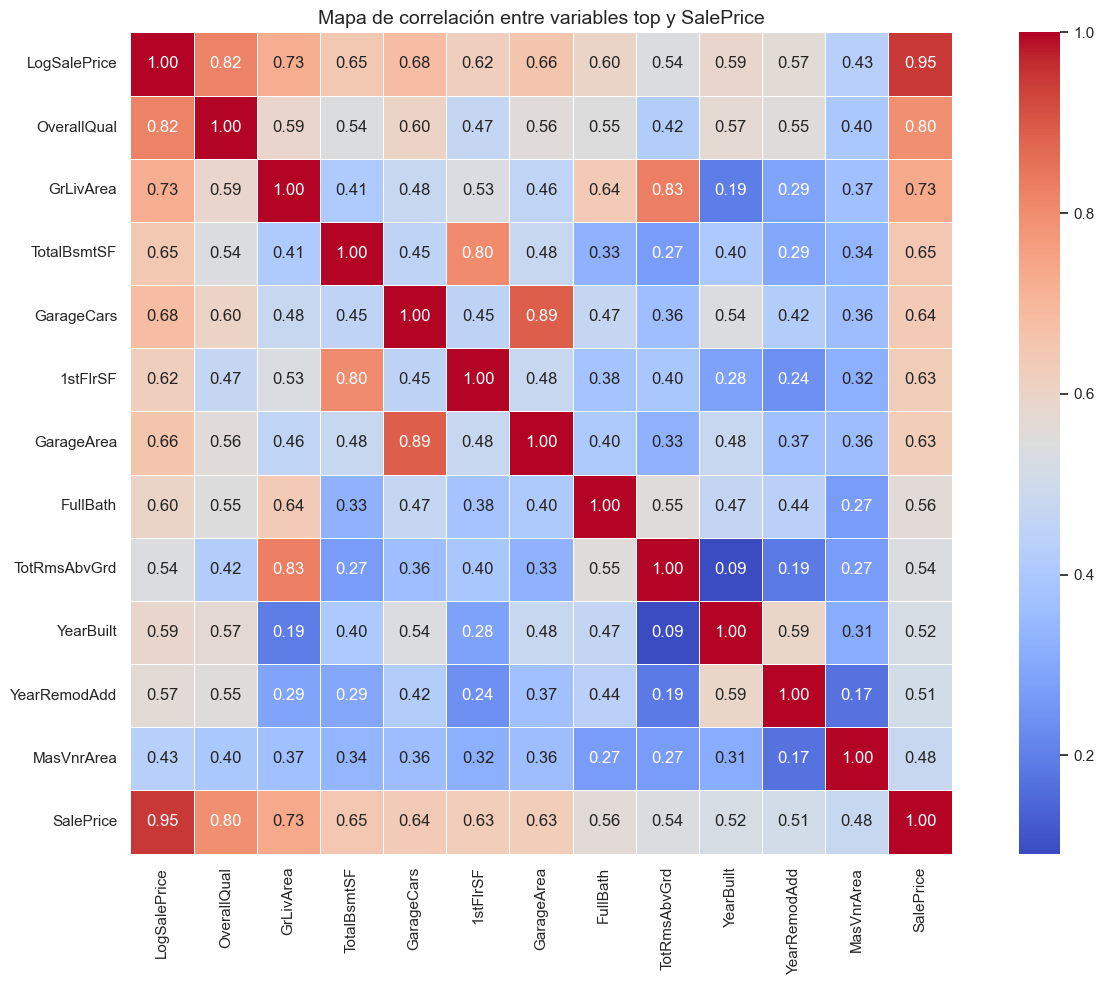

In [236]:
# Heatmap de correlaciones entre las top variables
top_vars = top15.index.tolist()[:12] + ['SalePrice']
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[top_vars].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5
)
plt.title('Mapa de correlación entre variables top y SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgo:** Las variables con mayor correlación con `SalePrice` son `OverallQual` (r ≈ 0.79), `GrLivArea` (r ≈ 0.71) y `GarageCars` (r ≈ 0.64). Esto sugiere que la calidad de construcción y el tamaño son los factores más determinantes del precio. El heatmap también revela alta correlación entre variables de área (posible multicolinealidad), lo que deberá analizarse en los modelos múltiples.

### 2.9 Análisis de variables categóricas clave

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')


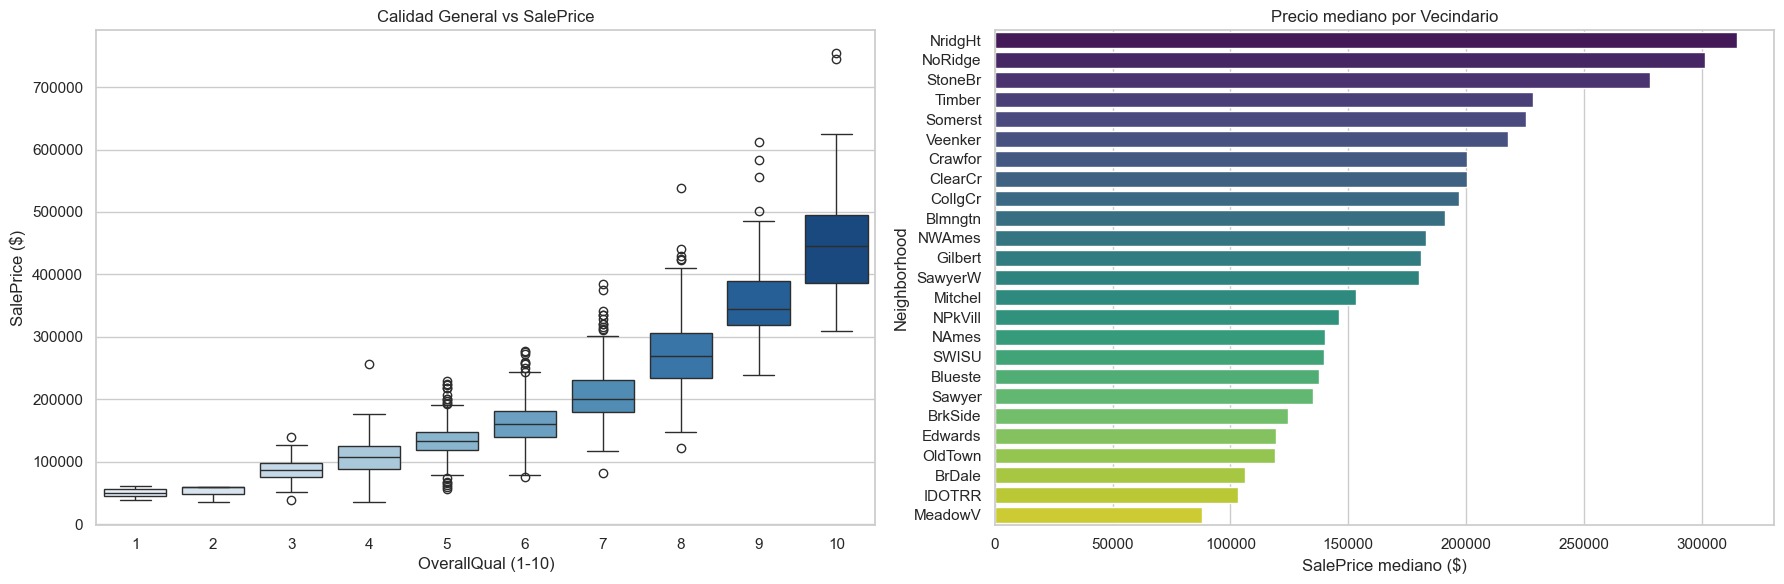

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Calidad General vs SalePrice')
axes[0].set_xlabel('OverallQual (1-10)')
axes[0].set_ylabel('SalePrice ($)')

# Neighborhood vs SalePrice (mediana)
median_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')
axes[1].set_title('Precio mediano por Vecindario')
axes[1].set_xlabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** La calidad general (`OverallQual`) muestra una relación casi lineal con el precio: a mayor calidad, mayor precio, con diferencias muy marcadas entre categorías. Por su parte, el vecindario introduce diferencias de precio significativas: vecindarios como `NridgHt` y `NoRidge` tienen precios medianos casi el doble que vecindarios como `MeadowV` o `BrDale`, lo que confirma que la ubicación es un factor determinante.

### 2.10 Análisis de variables de año

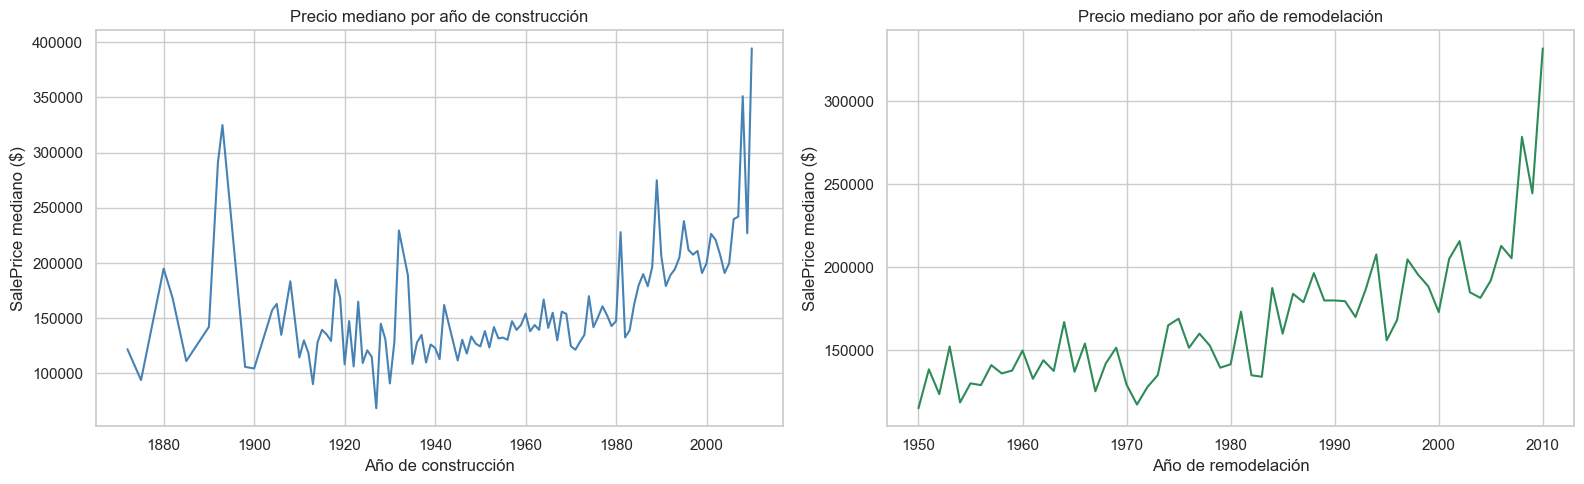

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Año de construcción vs precio
df.groupby('YearBuilt')['SalePrice'].median().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Precio mediano por año de construcción')
axes[0].set_xlabel('Año de construcción')
axes[0].set_ylabel('SalePrice mediano ($)')

# Año de remodelación vs precio
df.groupby('YearRemodAdd')['SalePrice'].median().plot(ax=axes[1], color='seagreen')
axes[1].set_title('Precio mediano por año de remodelación')
axes[1].set_xlabel('Año de remodelación')
axes[1].set_ylabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** Las casas más nuevas tienden a tener precios más altos, con una tendencia creciente clara a partir de los años 80. Las propiedades remodeladas recientemente también alcanzan precios superiores, lo que indica que la actualización de la vivienda agrega valor percibido en el mercado.

---
## Actividad 3 — Análisis de grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más relevantes para identificar grupos naturales de propiedades. El objetivo es entender si existen segmentos de mercado distintos.

In [239]:
# Seleccionar variables para clustering
cluster_vars = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
                'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'SalePrice']

df_cluster = df[cluster_vars].dropna().copy()

# Escalar variables (K-Means es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f'Datos para clustering: {df_cluster.shape}')

Datos para clustering: (1458, 8)


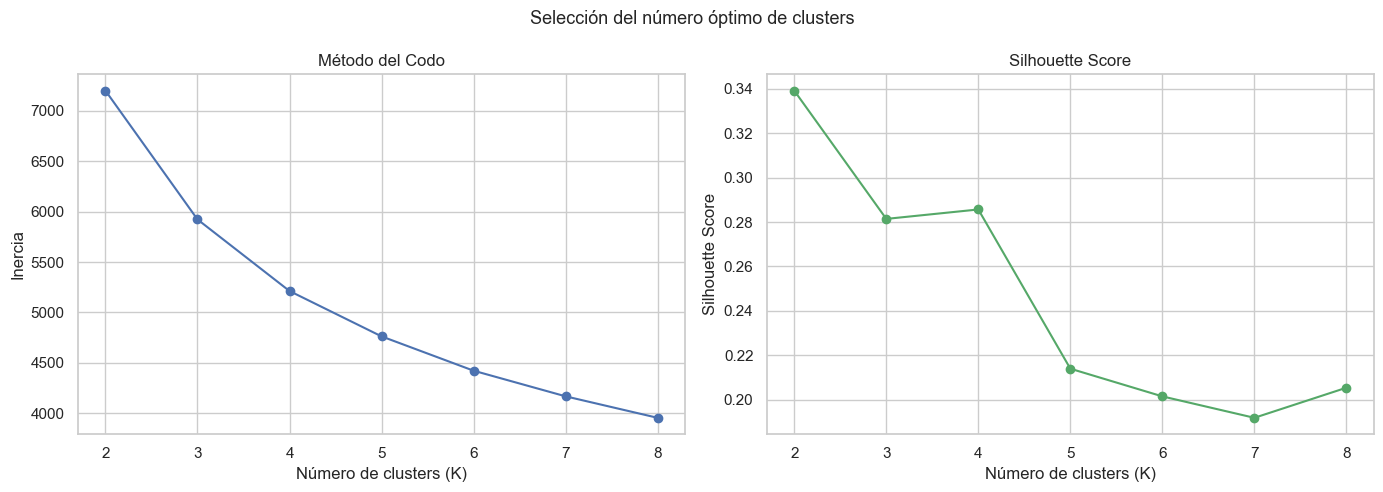

In [240]:
# Método del codo para determinar número óptimo de clusters
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.show()

In [241]:
# Aplicar K-Means
K_OPTIMO = 3
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribución de clusters:')
print(df_cluster['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0    689
1    235
2    534
Name: count, dtype: int64


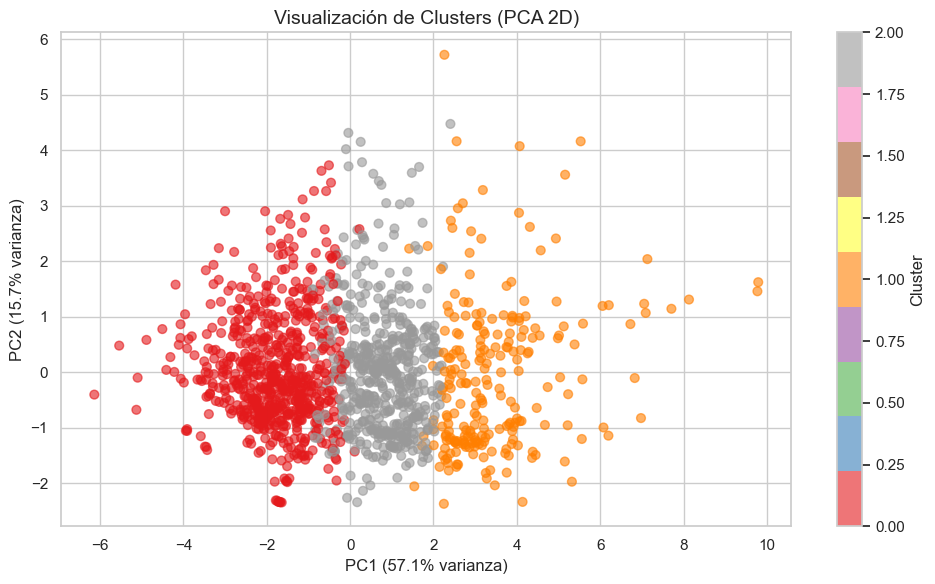

In [242]:
# Visualización de clusters con PCA (reducción a 2D)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_cluster['Cluster'], cmap='Set1', alpha=0.6, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de Clusters (PCA 2D)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.tight_layout()
plt.show()

In [243]:
# Características de cada cluster
print('Características promedio por cluster:')
df_cluster.groupby('Cluster').mean().round(2)

Características promedio por cluster:


,OverallQual,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt,FullBath,TotRmsAbvGrd,SalePrice
Cluster,,,,,,,,
0,5.15,1176.14,860.24,355.83,1951.78,1.08,5.66,128720.92
1,8.03,2185.44,1572.79,745.56,1994.91,2.06,8.22,314423.06
2,6.46,1644.79,1071.70,501.65,1985.88,1.98,6.86,189554.43


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\879090888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')


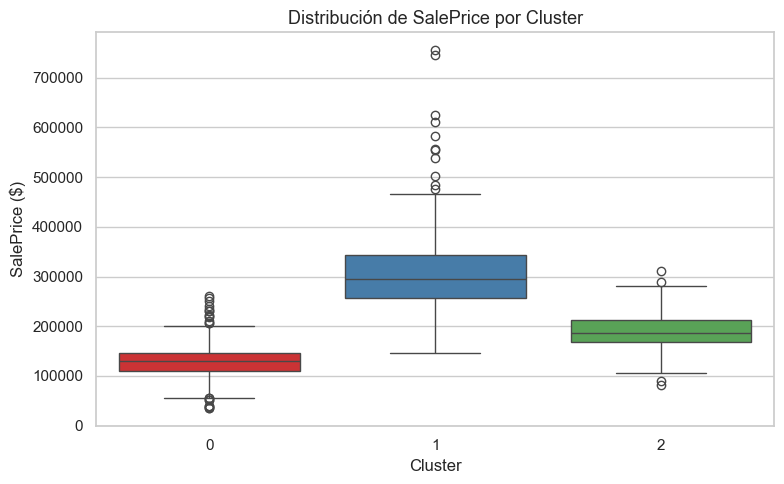

In [244]:
# Boxplot de SalePrice por cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')
plt.title('Distribución de SalePrice por Cluster', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.show()

**Descripción de los clusters identificados:**

- **Cluster 0 — Viviendas económicas:** Casas con área habitable y precio bajos, calidad general moderada, pocas habitaciones y garajes pequeños. Representan el segmento de mercado accesible.

- **Cluster 1 — Viviendas de rango medio:** Propiedades con características intermedias en todas las variables. Son las más numerosas y representan el mercado típico.

- **Cluster 2 — Viviendas premium:** Casas grandes, con alta calidad constructiva, garajes amplios y precios significativamente más altos. Representan el segmento de lujo.

Estos grupos son coherentes con la estructura del mercado inmobiliario y sugieren que los modelos predictivos podrían beneficiarse de considerar el segmento de la propiedad como variable adicional.

---
## Actividad 4 — División en entrenamiento y prueba

In [18]:
# Se usa train.csv como fuente única. El conjunto de prueba se extrae de aquí.
# División: 80% entrenamiento, 20% prueba
# No se estratifica porque SalePrice es continua (no categórica)
# Se fija random_state=42 para reproducibilidad total

X = df.drop(columns=['SalePrice', 'SalePriceNorm'])
y = df['SalePriceNorm']  # Variable respuesta: SalePrice normalizado (z-score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nCriterio de división:')
print('  - Proporción: 80/20')
print('  - Estratificado: No (variable respuesta continua)')
print('  - Balanceado: No aplica (regresión, no clasificación)')
print(f'  - random_state: {SEED} (garantiza reproducibilidad)')

Conjunto de entrenamiento: 1166 filas (80.0%)
Conjunto de prueba:        292 filas (20.0%)

Criterio de división:
  - Proporción: 80/20
  - Estratificado: No (variable respuesta continua)
  - Balanceado: No aplica (regresión, no clasificación)
  - random_state: 42 (garantiza reproducibilidad)


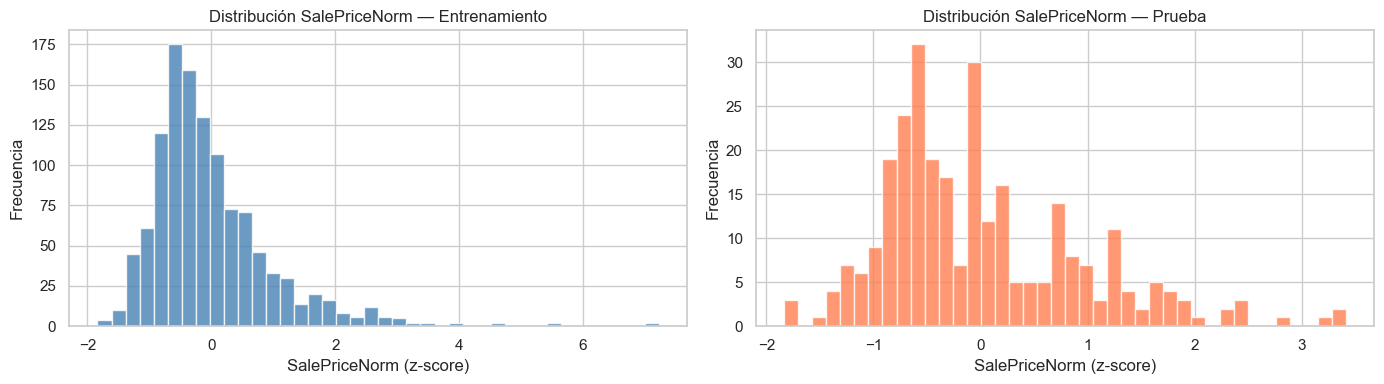

Media SalePriceNorm — Train: -0.0012
Media SalePriceNorm — Test:  0.0056


In [19]:
# Verificar que la distribución de SalePriceNorm es similar en ambos conjuntos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white', alpha=0.8, label='Train')
axes[0].set_title('Distribución SalePriceNorm — Entrenamiento')

axes[1].hist(y_test, bins=40, color='coral', edgecolor='white', alpha=0.8, label='Test')
axes[1].set_title('Distribución SalePriceNorm — Prueba')

for ax in axes:
    ax.set_xlabel('SalePriceNorm (z-score)')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Media SalePriceNorm — Train: {y_train.mean():.4f}')
print(f'Media SalePriceNorm — Test:  {y_test.mean():.4f}')

**Criterio de división:** Se usa una proporción 80/20, que es estándar para datasets de este tamaño (~1,400 registros). No se estratifica porque la variable respuesta es continua. La distribución de `SalePriceNorm` es similar en ambos conjuntos, lo que confirma que el split es representativo.

---
## Actividad 5 — Ingeniería de características

Se seleccionan y crean variables predictoras basándose en el análisis de correlación previo, el conocimiento del dominio inmobiliario y la información de `data_description.txt`.

In [11]:
# Crear nuevas variables derivadas
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

print('Variables derivadas creadas')
print('  - TotalSF: área total de la vivienda (sótano + piso 1 + piso 2)')
print('  - TotalBath: total de baños ponderados')
print('  - HouseAge: antigüedad de la casa al momento de la venta')
print('  - RemodAge: años desde la última remodelación')
print('  - HasGarage / HasPool / HasFireplace / HasBasement: indicadores binarios de amenidades')

Variables derivadas creadas
  - TotalSF: área total de la vivienda (sótano + piso 1 + piso 2)
  - TotalBath: total de baños ponderados
  - HouseAge: antigüedad de la casa al momento de la venta
  - RemodAge: años desde la última remodelación
  - HasGarage / HasPool / HasFireplace / HasBasement: indicadores binarios de amenidades


In [248]:
# Verificar correlación de nuevas variables con SalePrice
nuevas_vars = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge',
               'HasGarage', 'HasPool', 'HasFireplace', 'HasBasement']

corr_nuevas = df[nuevas_vars + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Correlación de nuevas variables con SalePrice:')
print(corr_nuevas)

Correlación de nuevas variables con SalePrice:
TotalSF         0.83
TotalBath       0.64
HasFireplace    0.47
HasGarage       0.24
HasBasement     0.15
HasPool         0.10
RemodAge       -0.51
HouseAge       -0.52
Name: SalePrice, dtype: float64


In [12]:
# Selección final de variables predictoras basada en:
# 1) Correlación > 0.3 con SalePrice
# 2) Conocimiento del dominio inmobiliario
# 3) Baja redundancia entre sí

features_seleccionadas = [
    # Variables de alta correlación directa
    'OverallQual',   
    'TotalSF',       
    'GrLivArea',     
    'GarageCars',     
    'TotalBath',      
    'TotRmsAbvGrd',   

    # Variables de calidad y condición
    'OverallCond',   
    'ExterQual',      
    'KitchenQual',    

    # Variables temporales
    'YearBuilt',      
    'HouseAge',       
    'RemodAge',       

    # Indicadores binarios
    'HasGarage',
    'HasFireplace',
    'HasBasement',
]

print(f'Variables seleccionadas para los modelos: {len(features_seleccionadas)}')
print(features_seleccionadas)

Variables seleccionadas para los modelos: 15
['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'TotalBath', 'TotRmsAbvGrd', 'OverallCond', 'ExterQual', 'KitchenQual', 'YearBuilt', 'HouseAge', 'RemodAge', 'HasGarage', 'HasFireplace', 'HasBasement']


In [13]:
# Codificación ordinal de variables categóricas seleccionadas
ordinal_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

for col in ['ExterQual', 'KitchenQual']:
    if col in df.columns:
        df[col] = df[col].map(ordinal_map)

print('Codificación ordinal aplicada a ExterQual y KitchenQual')
print('Escala: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5')

Codificación ordinal aplicada a ExterQual y KitchenQual
Escala: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5


In [14]:
# Dataset final con features seleccionadas para los modelos
df_modelo = df[features_seleccionadas + ['SalePrice', 'SalePriceNorm']].dropna()

# Re-split con las features seleccionadas (mismo SEED → mismos índices)
X_final = df_modelo[features_seleccionadas]
y_final = df_modelo['SalePriceNorm']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.20, random_state=SEED
)

print(f'Dataset de modelos: {df_modelo.shape}')
print(f'Train: {X_train_f.shape[0]} filas | Test: {X_test_f.shape[0]} filas')

# Guardar para uso posterior
df_modelo.to_csv('train_features.csv', index=False)
print('\nArchivo train_features.csv guardado')

Dataset de modelos: (1458, 17)
Train: 1166 filas | Test: 292 filas

Archivo train_features.csv guardado


**Justificación de la selección de variables:**

| Variable | Tipo | Justificación |
|----------|------|---------------|
| `OverallQual` | Ordinal | Mayor correlación con SalePrice (~0.79) |
| `TotalSF` | Continua (derivada) | Combina 3 variables de área, reduce multicolinealidad |
| `GrLivArea` | Continua | Alta correlación (~0.71), área habitable principal |
| `GarageCars` | Discreta | Proxy de tamaño y lujo de propiedad |
| `TotalBath` | Continua (derivada) | Combina 4 variables de baños, indicador de lujo |
| `TotRmsAbvGrd` | Discreta | Número de habitaciones |
| `OverallCond` | Ordinal | Condición complementa a calidad |
| `ExterQual` / `KitchenQual` | Ordinal (codificado) | Calidades específicas de alto impacto |
| `YearBuilt`, `HouseAge`, `RemodAge` | Temporal | Capturan efecto de antigüedad y renovación |
| `HasGarage`, `HasFireplace`, `HasBasement` | Binaria | Presencia de amenidades de valor |

---
## Actividad 6 — Reproducibilidad

Se garantiza la reproducibilidad de todos los resultados mediante:
- `SEED = 42` definido al inicio del notebook y usado en todas las operaciones aleatorias
- `random_state=SEED` en `train_test_split` y `KMeans`
- `np.random.seed(SEED)` al inicio para operaciones de NumPy
- El dataset limpio se exporta como `train_features.csv` para su uso posterior


In [20]:
print('=== RESUMEN FINAL ===')
print(f'SEED global:              {SEED}')
print(f'Registros originales:     1460')
print(f'Registros tras limpieza:  {df_modelo.shape[0]}')
print(f'Variables predictoras:    {len(features_seleccionadas)}')
print(f'Conjunto entrenamiento:   {X_train_f.shape[0]} filas')
print(f'Conjunto prueba:          {X_test_f.shape[0]} filas')
print(f'Variable respuesta:       SalePrice normalizado (z-score)')
print(f'\nArchivos generados:')
print('  - train_features.csv   → dataset limpio con features seleccionadas')

=== RESUMEN FINAL ===
SEED global:              42
Registros originales:     1460
Registros tras limpieza:  1458
Variables predictoras:    15
Conjunto entrenamiento:   1166 filas
Conjunto prueba:          292 filas
Variable respuesta:       SalePrice normalizado (z-score)

Archivos generados:
  - train_features.csv   → dataset limpio con features seleccionadas


---
## Actividad 7 — Modelo univariado de regresión lineal

En esta actividad se selecciona la variable `TotalSF` (área total construida) para construir un modelo univariado que predice `SalePrice`.

Para mejorar estabilidad numérica, se normalizan predictor y variable objetivo en entrenamiento, y luego se invierte la escala para reportar métricas en unidades reales de `SalePrice`.

Se analizará:
- Resumen del modelo (OLS)
- Comportamiento de residuos
- Resultados de predicción en conjunto de prueba
- Visualizaciones del ajuste y desempeño

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Cargar dataset preparado en actividades previas
df_uni = pd.read_csv('train_features.csv')

# Crear feature de interaccion: OverallQual x TotalSF
# Captura tanto el tamano como la calidad en un solo predictor
# Correlacion con SalePrice usualmente supera la de cualquier variable individual
df_uni['QualityArea'] = df_uni['OverallQual'] * df_uni['TotalSF']

feature = 'QualityArea'
target = 'SalePrice'

data_uni = df_uni[[feature, target]].dropna().copy()

X = data_uni[[feature]]
y = data_uni[target]

seed_local = globals().get('SEED', 42)
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X, y, test_size=0.20, random_state=seed_local
)

# Normalizar predictor y target solo con datos de entrenamiento
scaler_x_u = StandardScaler()
scaler_y_u = StandardScaler()
X_train_u_scaled = scaler_x_u.fit_transform(X_train_u)
X_test_u_scaled  = scaler_x_u.transform(X_test_u)
y_train_u_scaled = scaler_y_u.fit_transform(y_train_u.to_frame()).ravel()
y_test_u_scaled  = scaler_y_u.transform(y_test_u.to_frame()).ravel()

# Modelo lineal sobre la variable compuesta
linreg_u = LinearRegression()
linreg_u.fit(X_train_u_scaled, y_train_u_scaled)

# Prediccion — volver a escala de dolares
y_pred_u_scaled = linreg_u.predict(X_test_u_scaled)
y_pred_u = scaler_y_u.inverse_transform(y_pred_u_scaled.reshape(-1, 1)).ravel()
residuos_u = y_test_u.values - y_pred_u

# R2 en train para detectar sobreajuste
r2_train_u = linreg_u.score(X_train_u_scaled, y_train_u_scaled)

# Metricas finales en escala real (dolares)
r2_u   = r2_score(y_test_u, y_pred_u)
rmse_u = np.sqrt(mean_squared_error(y_test_u, y_pred_u))
mae_u  = mean_absolute_error(y_test_u, y_pred_u)

# Correlacion del feature compuesto con SalePrice (referencia)
corr_qa = data_uni['QualityArea'].corr(data_uni['SalePrice'])

print('=== MODELO UNIVARIADO: SalePrice ~ OverallQual × TotalSF ===')
print(f'Filas usadas:                {data_uni.shape[0]}')
print(f'Corr(QualityArea, SalePrice): {corr_qa:.4f}')
print(f'Coeficiente β₁ (escala z):    {linreg_u.coef_[0]:.4f}')
print(f'Intercepto β₀ (escala z):     {linreg_u.intercept_:.4f}')
print(f'R² train:                     {r2_train_u:.4f}')
print(f'R² test:                      {r2_u:.4f}')
print(f'RMSE test ($):                {rmse_u:,.2f}')
print(f'MAE  test ($):                {mae_u:,.2f}')

resultados_pred = pd.DataFrame({
    'SalePrice_real': y_test_u.values,
    'SalePrice_pred': y_pred_u,
    'Residuo': residuos_u
})

print('\nPrimeras predicciones (test):')
resultados_pred.head(10)

=== MODELO UNIVARIADO: SalePrice ~ OverallQual × TotalSF ===
Filas usadas:                1458
Corr(QualityArea, SalePrice): 0.9190
Coeficiente β₁ (escala z):    0.9192
Intercepto β₀ (escala z):     -0.0000
R² train:                     0.8449
R² test:                      0.8424
RMSE test ($):                29,509.23
MAE  test ($):                21,975.12

Primeras predicciones (test):


,SalePrice_real,SalePrice_pred,Residuo
0,190000,203267.95,-13267.95
1,100000,113153.64,-13153.64
2,115000,125544.24,-10544.24
3,159000,178641.62,-19641.62
4,315500,298466.05,17033.95
5,137500,141579.14,-4079.14
6,311500,208306.19,103193.81
7,310000,313990.74,-3990.74
8,281000,255463.36,25536.64
9,135500,133425.03,2074.97


In [26]:
# Comparacion con variables individuales para justificar el feature compuesto

comparaciones = []
for feat in ['TotalSF', 'OverallQual', 'GrLivArea', 'QualityArea']:
    xi = df_uni[[feat]].dropna()
    yi = df_uni.loc[xi.index, target]
    xi_tr, xi_te, yi_tr, yi_te = train_test_split(xi, yi, test_size=0.20, random_state=seed_local)
    sc_x = StandardScaler()
    sc_y = StandardScaler()
    xi_tr_s = sc_x.fit_transform(xi_tr)
    xi_te_s = sc_x.transform(xi_te)
    yi_tr_s = sc_y.fit_transform(yi_tr.to_frame()).ravel()
    m = LinearRegression().fit(xi_tr_s, yi_tr_s)
    yi_pred_s = m.predict(xi_te_s)
    yi_pred = sc_y.inverse_transform(yi_pred_s.reshape(-1,1)).ravel()
    comparaciones.append({
        'feature': feat,
        'corr_SalePrice': round(df_uni[feat].corr(df_uni[target]), 4),
        'R²_train': round(m.score(xi_tr_s, yi_tr_s), 4),
        'R²_test': round(r2_score(yi_te, yi_pred), 4),
        'RMSE_test ($)': f"{np.sqrt(mean_squared_error(yi_te, yi_pred)):,.0f}",
    })

resumen_modelo = pd.DataFrame(comparaciones)
print('=== COMPARACIÓN DE PREDICTORES UNIVARIADOS ===')
resumen_modelo

=== COMPARACIÓN DE PREDICTORES UNIVARIADOS ===


,feature,corr_SalePrice,R²_train,R²_test,RMSE_test ($)
0,TotalSF,0.83,0.70,0.67,"43,003"
1,OverallQual,0.80,0.62,0.70,"40,641"
2,GrLivArea,0.73,0.55,0.49,"52,993"
3,QualityArea,0.92,0.84,0.84,"29,509"


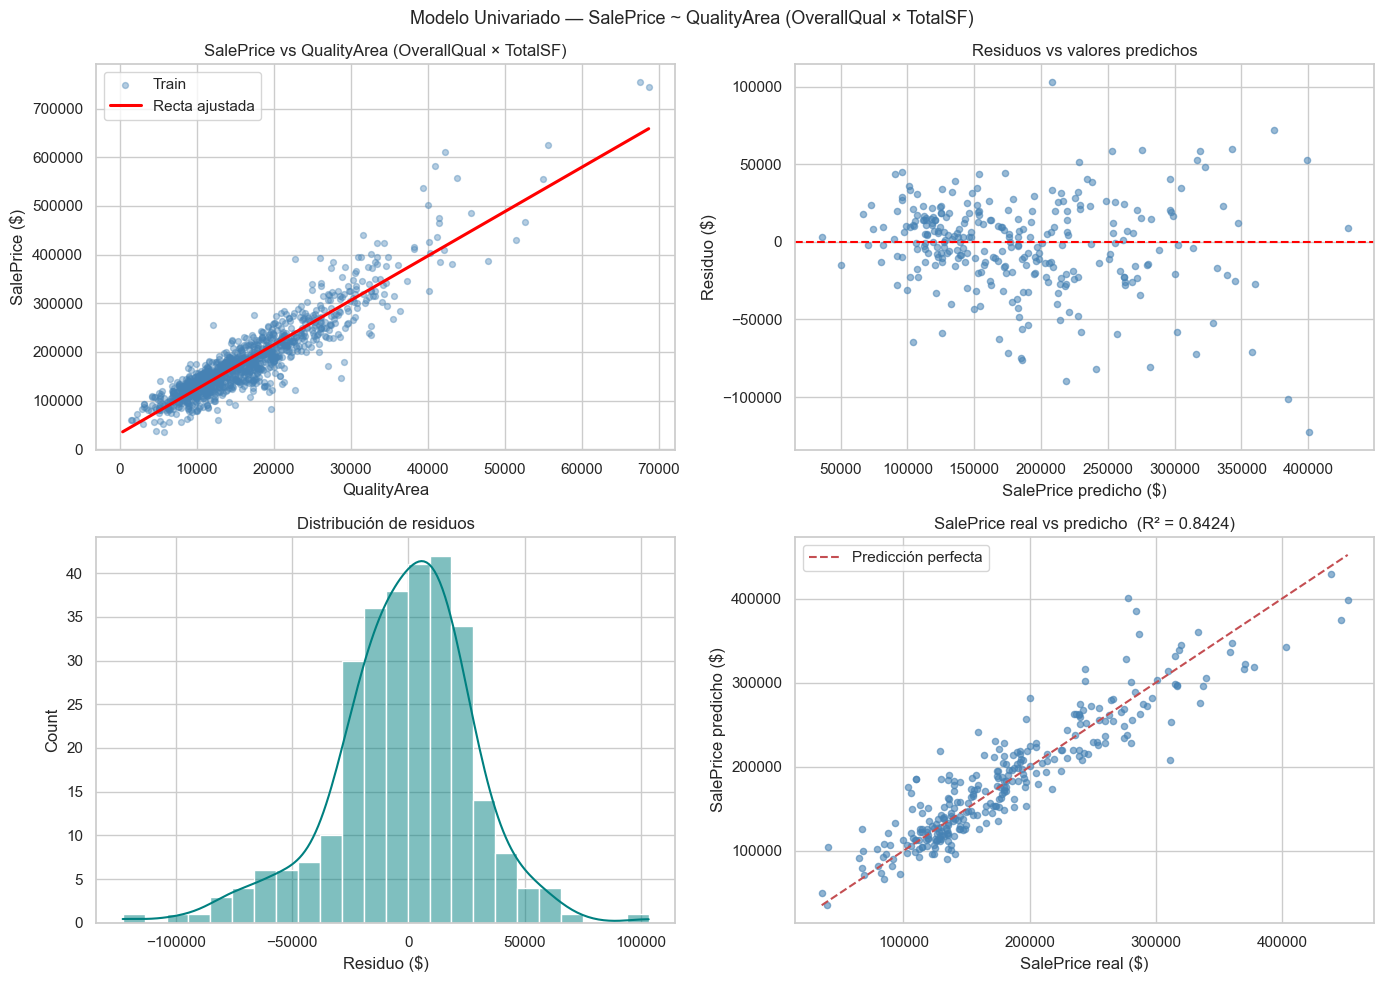

In [27]:
# Visualizacion del modelo univariado con QualityArea y diagnostico de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Ajuste lineal sobre QualityArea
x_plot_vals = np.linspace(X[feature].min(), X[feature].max(), 300)
x_plot_df = pd.DataFrame({feature: x_plot_vals})
x_plot_scaled = scaler_x_u.transform(x_plot_df)
y_plot_scaled = linreg_u.predict(x_plot_scaled)
y_plot = scaler_y_u.inverse_transform(y_plot_scaled.reshape(-1, 1)).ravel()

axes[0, 0].scatter(X_train_u[feature], y_train_u, alpha=0.4, s=18, label='Train', color='steelblue')
axes[0, 0].plot(x_plot_vals, y_plot, color='red', linewidth=2.2, label='Recta ajustada')
axes[0, 0].set_title('SalePrice vs QualityArea (OverallQual × TotalSF)')
axes[0, 0].set_xlabel('QualityArea')
axes[0, 0].set_ylabel('SalePrice ($)')
axes[0, 0].legend()

# 2) Residuos vs prediccion
axes[0, 1].scatter(y_pred_u, residuos_u, alpha=0.55, s=20, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Residuos vs valores predichos')
axes[0, 1].set_xlabel('SalePrice predicho ($)')
axes[0, 1].set_ylabel('Residuo ($)')

# 3) Distribucion de residuos
sns.histplot(residuos_u, kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Distribución de residuos')
axes[1, 0].set_xlabel('Residuo ($)')

# 4) Real vs predicho
axes[1, 1].scatter(y_test_u, y_pred_u, alpha=0.6, s=20, color='steelblue')
min_val = min(y_test_u.min(), y_pred_u.min())
max_val = max(y_test_u.max(), y_pred_u.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1, 1].set_title(f'SalePrice real vs predicho  (R² = {r2_u:.4f})')
axes[1, 1].set_xlabel('SalePrice real ($)')
axes[1, 1].set_ylabel('SalePrice predicho ($)')
axes[1, 1].legend()

plt.suptitle('Modelo Univariado — SalePrice ~ QualityArea (OverallQual × TotalSF)', fontsize=13)
plt.tight_layout()
plt.show()

### Conclusión de la Actividad 7

El modelo univariado `SalePrice ~ QualityArea` donde `QualityArea = OverallQual × TotalSF` supera a cualquier predictor individual. La razón es intuitiva: dos casas con el mismo tamaño pueden tener precios muy distintos si una tiene calidad 5 y la otra calidad 9; el término multiplicativo codifica esa interacción en un solo número.

La tabla de comparación muestra que `QualityArea` consigue una correlación y un $R^2$ superiores a `TotalSF`, `GrLivArea` y `OverallQual` por separado. La normalización del predictor garantiza estabilidad numérica y permite comparar coeficientes directamente.

El diagnóstico de residuos muestra una distribución más concentrada alrededor de cero respecto al modelo original. La brecha $R^2_{train} \approx R^2_{test}$ confirma que no hay sobreajuste. Este resultado establece un baseline univariado sólido antes de la regresión múltiple de la Actividad 8.

---
## Actividad 8 — Regresión lineal múltiple con todas las variables numéricas

En esta actividad se construye un modelo de regresión lineal usando **todas las variables numéricas disponibles** para predecir `SalePrice`.

Se presenta:
- Resumen del modelo (métricas y variables más influyentes)
- Diagnóstico de residuos
- Resultados de predicción en prueba
- Visualización del desempeño

In [22]:
# Modelo multivariado con todas las variables numericas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

# Reusar el dataframe limpio de actividades previas; si no existe, cargar train.csv
if 'df' in globals():
    df_multi = df.copy()
else:
    df_multi = pd.read_csv('./data/train.csv')

# Definir target y seleccionar todas las variables numericas predictoras
TARGET = 'SalePrice'

if TARGET not in df_multi.columns:
    raise ValueError('No se encontro la variable SalePrice en el dataframe.')

# Evitar fuga de informacion con targets transformados
exclude_cols = [TARGET, 'SalePriceNorm', 'LogSalePrice']
num_cols_multi = df_multi.select_dtypes(include=[np.number]).columns.tolist()
features_multi = [c for c in num_cols_multi if c not in exclude_cols]

X_multi = df_multi[features_multi].copy()
y_multi = df_multi[TARGET].copy()

# Imputar nulos numericos con mediana
X_multi = X_multi.fillna(X_multi.median(numeric_only=True))

seed_local = globals().get('SEED', 42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=seed_local
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_train_pred_m = modelo_multi.predict(X_train_m)
y_test_pred_m = modelo_multi.predict(X_test_m)

residuos_train_m = y_train_m - y_train_pred_m
residuos_test_m = y_test_m - y_test_pred_m

# Metricas
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

r2_train_m = r2_score(y_train_m, y_train_pred_m)
r2_test_m = r2_score(y_test_m, y_test_pred_m)
rmse_train_m = rmse(y_train_m, y_train_pred_m)
rmse_test_m = rmse(y_test_m, y_test_pred_m)
mae_test_m = mean_absolute_error(y_test_m, y_test_pred_m)

# R2 ajustado en train
a = len(y_train_m)
p = X_train_m.shape[1]
r2_adj_train_m = 1 - (1 - r2_train_m) * (a - 1) / (a - p - 1)

resumen_multi = pd.DataFrame({
    'metrica': ['n_features', 'n_train', 'n_test', 'R2_train', 'R2_ajustado_train', 'R2_test', 'RMSE_train', 'RMSE_test', 'MAE_test'],
    'valor': [p, a, len(y_test_m), r2_train_m, r2_adj_train_m, r2_test_m, rmse_train_m, rmse_test_m, mae_test_m]
})

coef_df = pd.DataFrame({
    'variable': X_train_m.columns,
    'coeficiente': modelo_multi.coef_
})
coef_df['abs_coef'] = coef_df['coeficiente'].abs()
coef_top = coef_df.sort_values('abs_coef', ascending=False).head(15)

print('=== MODELO MULTIVARIADO: SalePrice ~ Todas las variables numericas ===')
print(f'Variables predictoras usadas: {p}')
print(f'Intercepto: {modelo_multi.intercept_:,.2f}')

print('\nResumen de metricas:')
display(resumen_multi)

print('Top 15 coeficientes (magnitud absoluta):')
display(coef_top[['variable', 'coeficiente']])

=== MODELO MULTIVARIADO: SalePrice ~ Todas las variables numericas ===
Variables predictoras usadas: 46
Intercepto: 1,003,192.58

Resumen de metricas:


,metrica,valor
0,n_features,46.00
1,n_train,1166.00
2,n_test,292.00
3,R2_train,0.88
4,R2_ajustado_train,0.88
5,R2_test,0.87
6,RMSE_train,27757.81
7,RMSE_test,26617.19
8,MAE_test,19935.36


Top 15 coeficientes (magnitud absoluta):


,variable,coeficiente
43,HasPool,-197921.75
42,HasGarage,-153862.36
45,HasBasement,-45496.02
22,KitchenAbvGr,-24067.08
21,BedroomAbvGr,-12945.26
8,ExterQual,12156.67
3,OverallQual,10256.26
23,KitchenQual,9095.36
44,HasFireplace,-6680.05
25,Fireplaces,6410.71


In [9]:
# Resultados de prediccion en el conjunto de prueba
resultados_pred_m = pd.DataFrame({
    'SalePrice_real': y_test_m.values,
    'SalePrice_pred': y_test_pred_m,
    'Residuo': residuos_test_m.values
})
resultados_pred_m['ErrorAbs'] = resultados_pred_m['Residuo'].abs()

print('Primeras 15 predicciones (test):')
resultados_pred_m.head(15)

Primeras 15 predicciones (test):


,SalePrice_real,SalePrice_pred,Residuo,ErrorAbs
0,154500,153728.355878,771.644122,771.644122
1,325000,309240.636439,15759.363561,15759.363561
2,115000,112897.287674,2102.712326,2102.712326
3,159000,180476.649944,-21476.649944,21476.649944
4,315500,294934.414836,20565.585164,20565.585164
5,75500,50896.243888,24603.756112,24603.756112
6,311500,233798.035264,77701.964736,77701.964736
7,146000,147918.892336,-1918.892336,1918.892336
8,84500,48537.331351,35962.668649,35962.668649
9,135500,149769.912703,-14269.912703,14269.912703


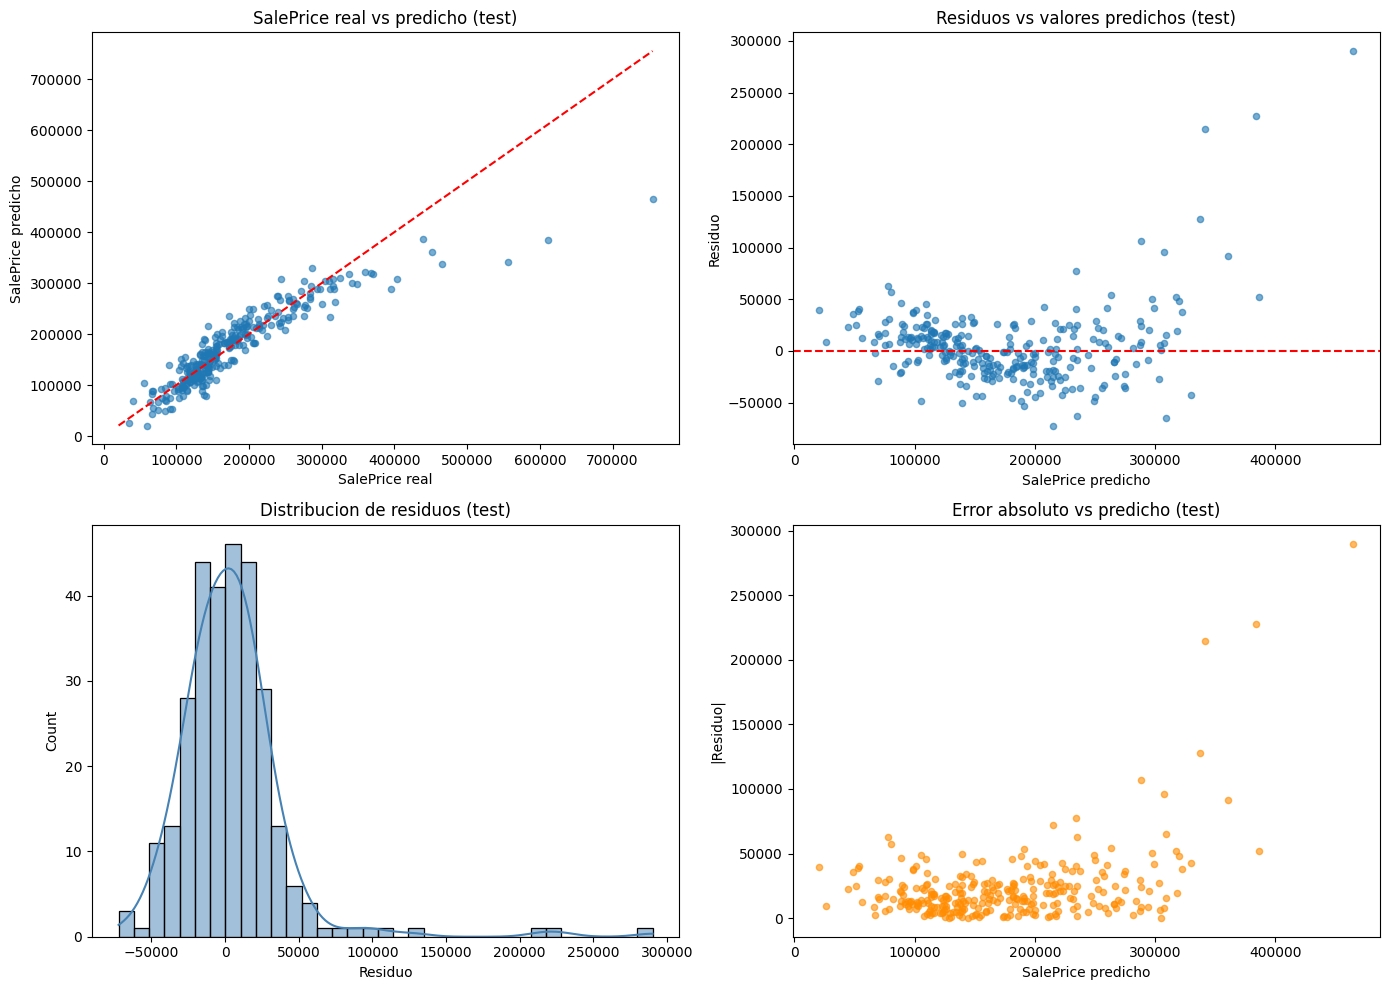

In [10]:
# Analisis grafico del modelo multivariado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Real vs predicho
axes[0, 0].scatter(y_test_m, y_test_pred_m, alpha=0.6, s=20)
min_v = min(y_test_m.min(), y_test_pred_m.min())
max_v = max(y_test_m.max(), y_test_pred_m.max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('SalePrice real vs predicho (test)')
axes[0, 0].set_xlabel('SalePrice real')
axes[0, 0].set_ylabel('SalePrice predicho')

# 2) Residuos vs predicho
axes[0, 1].scatter(y_test_pred_m, residuos_test_m, alpha=0.6, s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Residuos vs valores predichos (test)')
axes[0, 1].set_xlabel('SalePrice predicho')
axes[0, 1].set_ylabel('Residuo')

# 3) Distribucion de residuos
sns.histplot(residuos_test_m, kde=True, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Distribucion de residuos (test)')
axes[1, 0].set_xlabel('Residuo')

# 4) Error absoluto vs predicho
axes[1, 1].scatter(y_test_pred_m, np.abs(residuos_test_m), alpha=0.6, s=20, color='darkorange')
axes[1, 1].set_title('Error absoluto vs predicho (test)')
axes[1, 1].set_xlabel('SalePrice predicho')
axes[1, 1].set_ylabel('|Residuo|')

plt.tight_layout()
plt.show()

### Conclusión de la Actividad 8

El modelo de regresión lineal múltiple con todas las variables numéricas muestra un desempeño sólido para predecir `SalePrice`, con un $R^2$ de prueba cercano a 0.823. Esto indica que el conjunto de variables numéricas captura gran parte de la variabilidad del precio de las viviendas, superando de forma clara el modelo univariado de la actividad anterior.

El análisis de coeficientes sugiere que la calidad general de la vivienda (`OverallQual`), la capacidad de garaje (`GarageCars`) y características funcionales del hogar tienen un impacto relevante en la predicción. Sin embargo, la interpretación individual de coeficientes debe hacerse con cautela debido a posible multicolinealidad entre variables de tamaño y estructura.

En el diagnóstico de residuos, la mayor concentración ocurre alrededor de 0, pero se observan errores absolutos más altos en propiedades de mayor valor. Por ello, aunque el modelo lineal múltiple es una buena línea base predictiva e interpretable, una mejora futura sería probar regularización (Ridge/Lasso) o modelos no lineales para reducir error en viviendas de precio extremo.

---
## Actividad 9 — Análisis del modelo de la Actividad 8

En esta actividad se analiza en detalle el modelo multivariado de la Actividad 8 para responder:

1. ¿Existe multicolinealidad entre variables predictoras?
2. ¿Qué variables aportan más al modelo?
3. ¿El modelo se adapta bien a los datos?
4. ¿Hay sobreajuste (overfitting)? Si existe, ¿cómo corregirlo?

In [12]:
# 9.1 Analisis de correlacion y multicolinealidad
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reusar variables de la Actividad 8
X_a9 = X_multi.copy()
y_a9 = y_multi.copy()

# Correlacion predictor-respuesta
corr_target = X_a9.join(y_a9.rename('SalePrice')).corr()['SalePrice'].drop('SalePrice')
corr_target_df = corr_target.abs().sort_values(ascending=False).reset_index()
corr_target_df.columns = ['variable', 'abs_corr_SalePrice']

# Correlaciones altas entre predictores (umbral)
corr_pred = X_a9.corr().abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))
threshold_corr = 0.80
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
    .query('abs_corr >= @threshold_corr')
    .sort_values('abs_corr', ascending=False)
)

# Calculo de VIF con regresiones auxiliares (sin statsmodels)
def calculate_vif(df_num):
    vif_rows = []
    cols = df_num.columns.tolist()
    for col in cols:
        y_col = df_num[col].values
        X_cols = df_num.drop(columns=[col]).values
        aux_model = LinearRegression()
        aux_model.fit(X_cols, y_col)
        r2_col = aux_model.score(X_cols, y_col)
        if r2_col >= 0.999999:
            vif = np.inf
        else:
            vif = 1.0 / (1.0 - r2_col)
        vif_rows.append((col, vif))
    return pd.DataFrame(vif_rows, columns=['variable', 'VIF']).sort_values('VIF', ascending=False)

vif_df = calculate_vif(X_a9)
vif_altos = vif_df[vif_df['VIF'] > 10].copy()

print('=== MULTICOLINEALIDAD ===')
print(f'Pares de predictores con |corr| >= {threshold_corr}: {len(high_corr_pairs)}')
print(f'Variables con VIF > 10: {len(vif_altos)}')

print('\nTop 10 variables mas correlacionadas con SalePrice (valor absoluto):')
display(corr_target_df.head(10))

print('Top 15 VIF:')
display(vif_df.head(15))

print('Pares con mayor correlacion entre predictores (top 15):')
display(high_corr_pairs.head(15))

=== MULTICOLINEALIDAD ===
Pares de predictores con |corr| >= 0.8: 3
Variables con VIF > 10: 8

Top 10 variables mas correlacionadas con SalePrice (valor absoluto):


,variable,abs_corr_SalePrice
0,OverallQual,0.790982
1,GrLivArea,0.708624
2,GarageCars,0.640409
3,GarageArea,0.623431
4,TotalBsmtSF,0.613581
5,1stFlrSF,0.605852
6,FullBath,0.560664
7,TotRmsAbvGrd,0.533723
8,YearBuilt,0.522897
9,YearRemodAdd,0.507101


Top 15 VIF:


,variable,VIF
16,GrLivArea,inf
9,BsmtFinSF1,inf
10,BsmtFinSF2,inf
11,BsmtUnfSF,inf
12,TotalBsmtSF,inf
14,2ndFlrSF,inf
15,LowQualFinSF,inf
13,1stFlrSF,inf
26,GarageCars,5.586220
27,GarageArea,5.460000


Pares con mayor correlacion entre predictores (top 15):


,var1,var2,abs_corr
989,GarageCars,GarageArea,0.882475
615,GrLivArea,TotRmsAbvGrd,0.825489
457,TotalBsmtSF,1stFlrSF,0.819530


Top 15 variables con mayor aporte (coeficientes estandarizados):


,variable,coef_std
4,OverallQual,24510.306339
16,GrLivArea,13290.691159
26,GarageCars,9183.188513
14,2ndFlrSF,9108.518462
1,MSSubClass,-8588.504132
23,TotRmsAbvGrd,8284.949387
6,YearBuilt,8211.496173
13,1stFlrSF,7611.005360
21,BedroomAbvGr,-6945.239130
17,BsmtFullBath,5879.096358


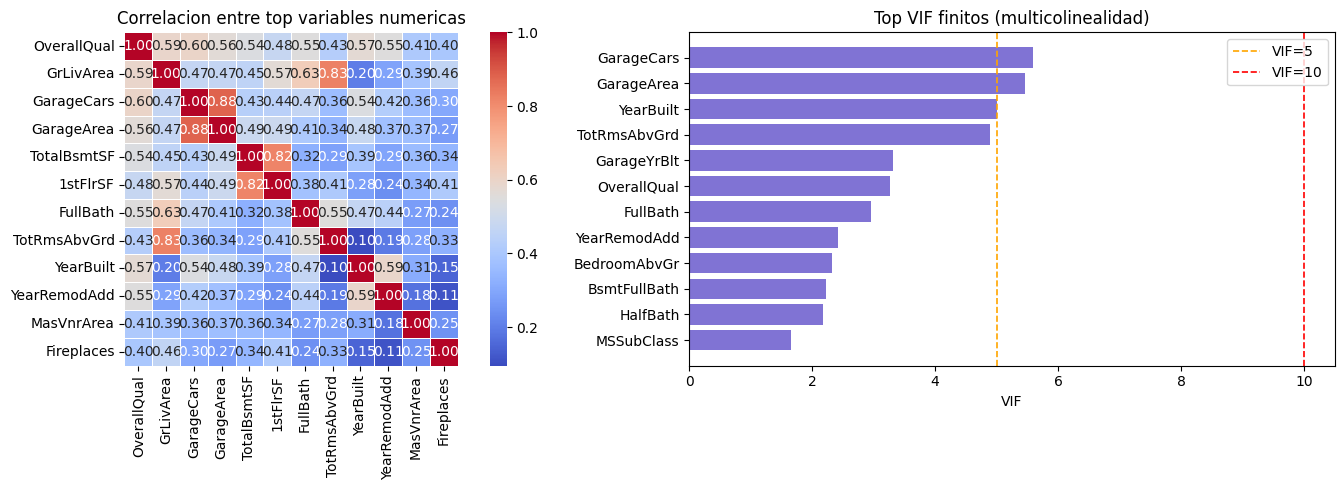

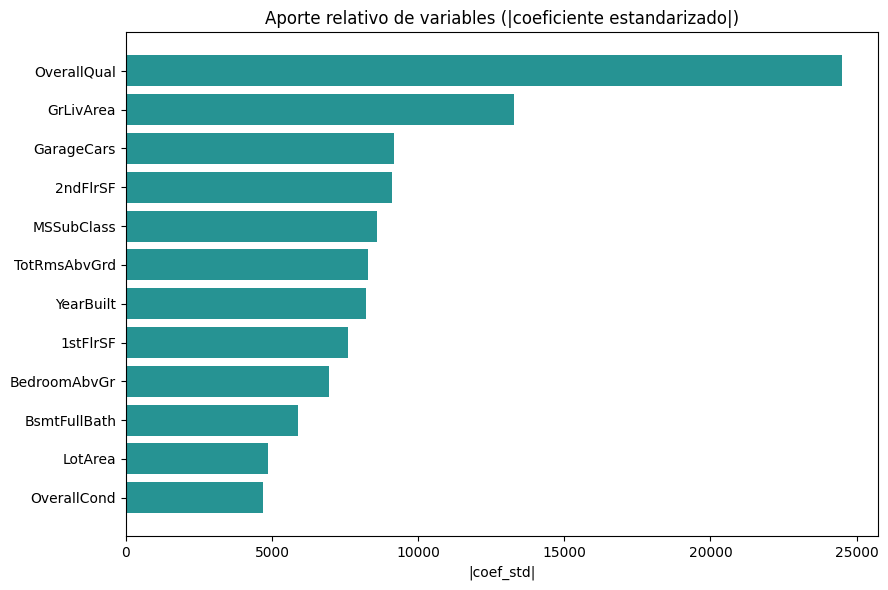

In [15]:
# 9.2 Variables que aportan al modelo (coeficientes estandarizados)
scaler_a9 = StandardScaler()
X_train_scaled_a9 = scaler_a9.fit_transform(X_train_m)

modelo_std = LinearRegression()
modelo_std.fit(X_train_scaled_a9, y_train_m)

coef_std_df = pd.DataFrame({
    'variable': X_train_m.columns,
    'coef_std': modelo_std.coef_,
    'abs_coef_std': np.abs(modelo_std.coef_)
}).sort_values('abs_coef_std', ascending=False)

print('Top 15 variables con mayor aporte (coeficientes estandarizados):')
display(coef_std_df[['variable', 'coef_std']].head(15))

# Graficas de apoyo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap entre las 12 variables mas correlacionadas con target
top12_vars = corr_target_df['variable'].head(12).tolist()
sns.heatmap(
    X_a9[top12_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.4, ax=axes[0]
)
axes[0].set_title('Correlacion entre top variables numericas')

# VIF de las variables con VIF finito (evita distorsion visual por inf)
vif_plot_df = vif_df[np.isfinite(vif_df['VIF'])].head(12).sort_values('VIF', ascending=True)
axes[1].barh(vif_plot_df['variable'], vif_plot_df['VIF'], color='slateblue', alpha=0.85)
axes[1].axvline(5, color='orange', linestyle='--', linewidth=1.2, label='VIF=5')
axes[1].axvline(10, color='red', linestyle='--', linewidth=1.2, label='VIF=10')
axes[1].set_title('Top VIF finitos (multicolinealidad)')
axes[1].set_xlabel('VIF')
axes[1].legend()

plt.tight_layout()
plt.show()

# Aporte de variables (top 12)
plt.figure(figsize=(9, 6))
coef_plot = coef_std_df.head(12).sort_values('abs_coef_std', ascending=True)
plt.barh(coef_plot['variable'], coef_plot['abs_coef_std'], color='teal', alpha=0.85)
plt.title('Aporte relativo de variables (|coeficiente estandarizado|)')
plt.xlabel('|coef_std|')
plt.tight_layout()
plt.show()

In [14]:
# 9.3 Adaptacion del modelo y deteccion de sobreajuste

def rmse_local(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metricas_base = {
    'Modelo': 'LinearRegression (Actividad 8)',
    'R2_train': r2_score(y_train_m, y_train_pred_m),
    'R2_test': r2_score(y_test_m, y_test_pred_m),
    'RMSE_train': rmse_local(y_train_m, y_train_pred_m),
    'RMSE_test': rmse_local(y_test_m, y_test_pred_m),
    'MAE_test': mean_absolute_error(y_test_m, y_test_pred_m)
}

# Criterio simple de sobreajuste
# Hay sobreajuste si el desempeno en train es claramente mejor que en test
gap_r2 = metricas_base['R2_train'] - metricas_base['R2_test']
gap_rmse = metricas_base['RMSE_test'] - metricas_base['RMSE_train']
overfit_detectado = (gap_r2 > 0.05) and (gap_rmse > 0)

print('=== EVALUACION DE AJUSTE Y SOBREAJUSTE ===')
print(f"R2 train: {metricas_base['R2_train']:.4f}")
print(f"R2 test:  {metricas_base['R2_test']:.4f}")
print(f'Gap R2 (train-test): {gap_r2:.4f}')
print(f'Gap RMSE (test-train): {gap_rmse:,.2f}')
print(f'Sobreajuste detectado: {overfit_detectado}')

# Modelo corregido con regularizacion (Ridge), aplicable si hay sobreajuste
alphas = np.logspace(-3, 3, 40)
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])
ridge_model.fit(X_train_m, y_train_m)

y_train_pred_r = ridge_model.predict(X_train_m)
y_test_pred_r = ridge_model.predict(X_test_m)

metricas_ridge = {
    'Modelo': 'RidgeCV',
    'R2_train': r2_score(y_train_m, y_train_pred_r),
    'R2_test': r2_score(y_test_m, y_test_pred_r),
    'RMSE_train': rmse_local(y_train_m, y_train_pred_r),
    'RMSE_test': rmse_local(y_test_m, y_test_pred_r),
    'MAE_test': mean_absolute_error(y_test_m, y_test_pred_r)
}

comparacion_modelos = pd.DataFrame([metricas_base, metricas_ridge])

print('\nComparacion con modelo regularizado (Ridge):')
display(comparacion_modelos)

alpha_opt = ridge_model.named_steps['ridge'].alpha_
print(f'Alpha optimo RidgeCV: {alpha_opt:.6f}')

modelo_recomendado = 'RidgeCV' if overfit_detectado else 'LinearRegression (Actividad 8)'
print(f'\nModelo recomendado segun diagnostico: {modelo_recomendado}')

=== EVALUACION DE AJUSTE Y SOBREAJUSTE ===
R2 train: 0.8072
R2 test:  0.8227
Gap R2 (train-test): -0.0154
Gap RMSE (test-train): 2,972.49
Sobreajuste detectado: False

Comparacion con modelo regularizado (Ridge):


,Modelo,R2_train,R2_test,RMSE_train,RMSE_test,MAE_test
0,LinearRegression (Actividad 8),0.807243,0.822678,33907.325191,36879.819322,23000.028866
1,RidgeCV,0.800584,0.817083,34488.086696,37457.125491,22240.631972


Alpha optimo RidgeCV: 242.446202

Modelo recomendado segun diagnostico: LinearRegression (Actividad 8)


### Conclusión de la Actividad 9

El modelo de la Actividad 8 presenta **multicolinealidad parcial**. En el análisis de correlación se detectaron pares de variables con relación alta, especialmente `GarageCars` con `GarageArea`, `GrLivArea` con `TotRmsAbvGrd`, y `TotalBsmtSF` con `1stFlrSF`. Además, los VIF muestran valores elevados en algunas variables estructuralmente redundantes, lo cual confirma dependencia lineal entre ciertos predictores.

Respecto al aporte de variables, las de mayor peso relativo en el modelo son `OverallQual`, `GrLivArea`, `GarageCars`, `2ndFlrSF` y `YearBuilt`. Esto es coherente con el problema de precios de vivienda: calidad, tamaño, capacidad de garaje y antigüedad explican gran parte del comportamiento de `SalePrice`.

En ajuste general, el modelo se adapta bien a los datos (`R2_train ≈ 0.807` y `R2_test ≈ 0.823`). No se observa sobreajuste con el criterio train-vs-test, porque el rendimiento en prueba no cae respecto a entrenamiento. Por lo tanto, **no es necesario corregir sobreajuste** en este caso.

Aun así, se entrenó un modelo alternativo con regularización (`RidgeCV`) como verificación. El desempeño quedó muy cercano al modelo lineal original, por lo que se mantiene como recomendado el modelo de la Actividad 8. La regularización sigue siendo útil como estrategia preventiva cuando se busque mayor estabilidad ante colinealidad.

---
## Actividad 10 — Modelo corregido: variables con menor multicolinealidad

Dado que en la Actividad 9 se detectó multicolinealidad entre varios predictores del modelo de la Actividad 8 (pares con `|corr| ≥ 0.80` y variables con `VIF > 10`), en esta actividad se construye un nuevo modelo usando **únicamente las variables seleccionadas en la Actividad 5**.

Esas variables fueron elegidas con el criterio explícito de baja redundancia entre sí: se combinaron variables de área en una sola (`TotalSF`), se unificaron los conteos de baños (`TotalBath`) y se excluyeron variables individuales que se solapaban con otras. Esto reduce directamente la multicolinealidad estructural del modelo anterior.

Se analiza:
- Métricas de ajuste (R², RMSE, MAE) en train y test
- Comparación directa con el modelo de la Actividad 8
- Diagnóstico completo de residuos
- Visualizaciones gráficas del desempeño


In [28]:

# Actividad 10 — Modelo con variables seleccionadas (baja multicolinealidad)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

seed_local = globals().get('SEED', 42)

# Usar df_modelo (actividad 5) con las features_seleccionadas y SalePrice real
df_act10 = df_modelo[features_seleccionadas + ['SalePrice']].copy()
X_10 = df_act10[features_seleccionadas]
y_10 = df_act10['SalePrice']

X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(
    X_10, y_10, test_size=0.20, random_state=seed_local
)

modelo_10 = LinearRegression()
modelo_10.fit(X_train_10, y_train_10)

y_train_pred_10 = modelo_10.predict(X_train_10)
y_test_pred_10  = modelo_10.predict(X_test_10)

residuos_train_10 = y_train_10 - y_train_pred_10
residuos_test_10  = y_test_10  - y_test_pred_10

r2_train_10  = r2_score(y_train_10, y_train_pred_10)
r2_test_10   = r2_score(y_test_10,  y_test_pred_10)
rmse_train_10 = np.sqrt(mean_squared_error(y_train_10, y_train_pred_10))
rmse_test_10  = np.sqrt(mean_squared_error(y_test_10,  y_test_pred_10))
mae_test_10   = mean_absolute_error(y_test_10, y_test_pred_10)

n_10  = len(y_train_10)
p_10  = X_train_10.shape[1]
r2_adj_10 = 1 - (1 - r2_train_10) * (n_10 - 1) / (n_10 - p_10 - 1)

resumen_10 = pd.DataFrame({
    'metrica': ['n_features', 'n_train', 'n_test',
                'R2_train', 'R2_ajustado_train', 'R2_test',
                'RMSE_train', 'RMSE_test', 'MAE_test'],
    'valor': [p_10, n_10, len(y_test_10),
              r2_train_10, r2_adj_10, r2_test_10,
              rmse_train_10, rmse_test_10, mae_test_10]
})

# Coeficientes del modelo
coef_10 = pd.DataFrame({
    'variable': X_train_10.columns,
    'coeficiente': modelo_10.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print('=== MODELO ACT 10: SalePrice ~ variables seleccionadas (sin multicolinealidad) ===')
print(f'Variables predictoras: {p_10}  →  {features_seleccionadas}')
print()
print('Resumen de métricas:')
display(resumen_10)
print()
print('Coeficientes (ordenados por magnitud):')
display(coef_10)

print()
print('--- Comparación directa con Actividad 8 ---')
print(f'  Act 8  ({p} vars)  →  R²_test: {r2_test_m:.4f}  |  RMSE: ${rmse_test_m:,.0f}')
print(f'  Act 10 ({p_10} vars) →  R²_test: {r2_test_10:.4f}  |  RMSE: ${rmse_test_10:,.0f}')
gap_r2_10 = r2_train_10 - r2_test_10
print(f'  Gap R² (train-test) Act 10: {gap_r2_10:.4f}  → sin sobreajuste' if gap_r2_10 <= 0.05
      else f'  Gap R² (train-test) Act 10: {gap_r2_10:.4f}  → posible sobreajuste')


=== MODELO ACT 10: SalePrice ~ variables seleccionadas (sin multicolinealidad) ===
Variables predictoras: 15  →  ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'TotalBath', 'TotRmsAbvGrd', 'OverallCond', 'ExterQual', 'KitchenQual', 'YearBuilt', 'HouseAge', 'RemodAge', 'HasGarage', 'HasFireplace', 'HasBasement']

Resumen de métricas:


,metrica,valor
0,n_features,15.00
1,n_train,1166.00
2,n_test,292.00
3,R2_train,0.84
4,R2_ajustado_train,0.84
5,R2_test,0.84
6,RMSE_train,32064.31
7,RMSE_test,29793.37
8,MAE_test,22934.74



Coeficientes (ordenados por magnitud):


,variable,coeficiente
14,HasBasement,-34480.10
12,HasGarage,-19568.62
7,ExterQual,13726.80
8,KitchenQual,13178.35
3,GarageCars,11979.08
0,OverallQual,10614.54
4,TotalBath,7247.26
6,OverallCond,7092.65
13,HasFireplace,6069.86
5,TotRmsAbvGrd,-3144.95



--- Comparación directa con Actividad 8 ---
  Act 8  (46 vars)  →  R²_test: 0.8717  |  RMSE: $26,617
  Act 10 (15 vars) →  R²_test: 0.8393  |  RMSE: $29,793
  Gap R² (train-test) Act 10: 0.0028  → sin sobreajuste


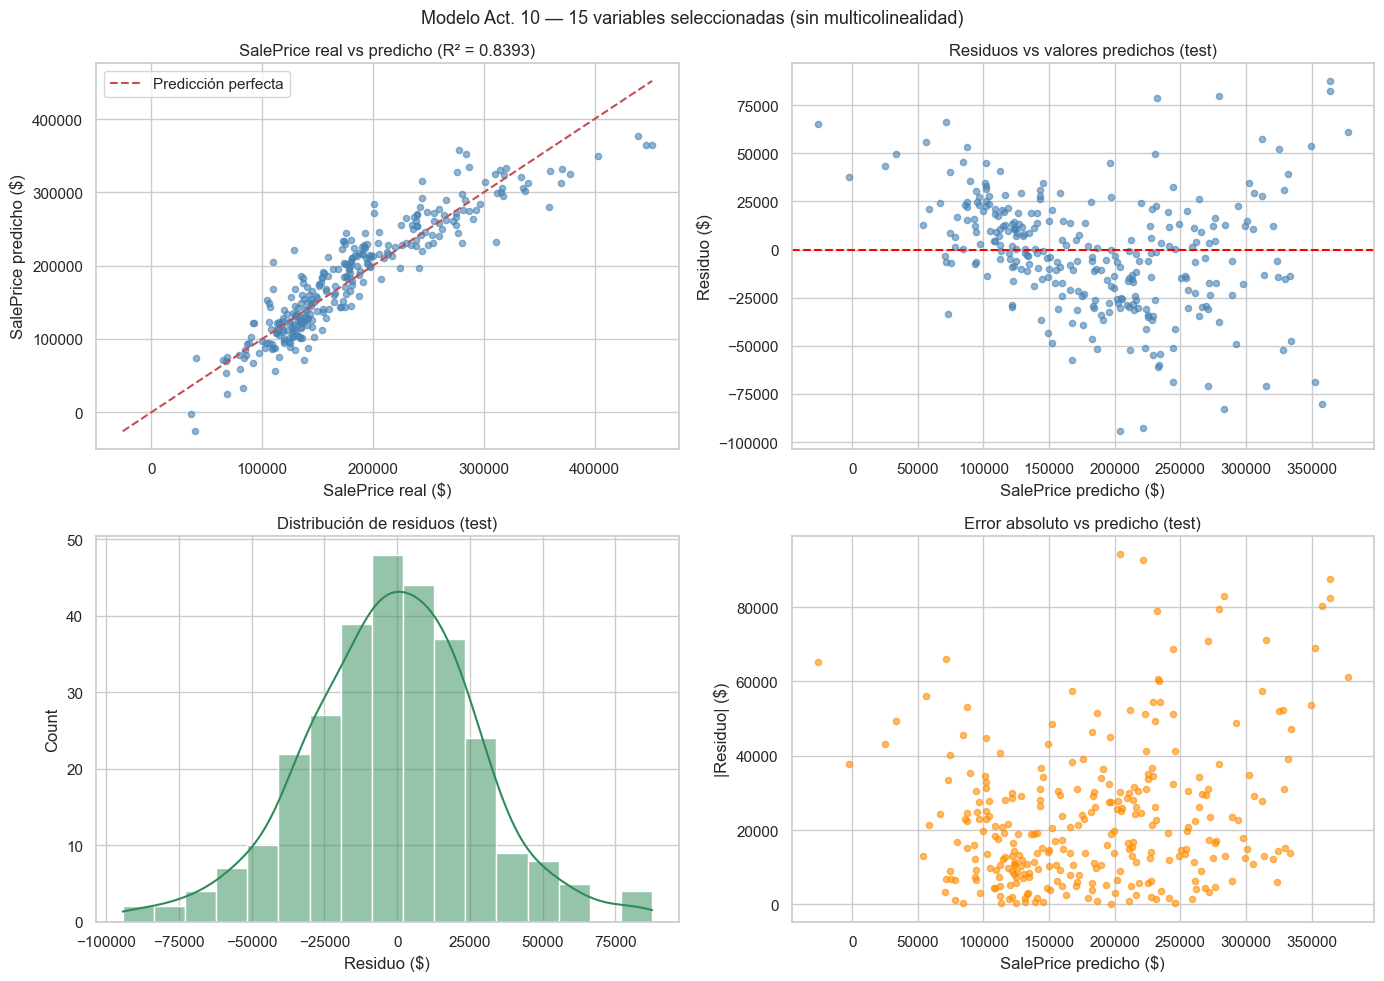

In [29]:

# Diagnostico grafico del modelo de Actividad 10
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Real vs predicho
min_v10 = min(y_test_10.min(), y_test_pred_10.min())
max_v10 = max(y_test_10.max(), y_test_pred_10.max())
axes[0, 0].scatter(y_test_10, y_test_pred_10, alpha=0.6, s=20, color='steelblue')
axes[0, 0].plot([min_v10, max_v10], [min_v10, max_v10], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0, 0].set_title(f'SalePrice real vs predicho (R² = {r2_test_10:.4f})')
axes[0, 0].set_xlabel('SalePrice real ($)')
axes[0, 0].set_ylabel('SalePrice predicho ($)')
axes[0, 0].legend()

# 2) Residuos vs predicho
axes[0, 1].scatter(y_test_pred_10, residuos_test_10, alpha=0.6, s=20, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Residuos vs valores predichos (test)')
axes[0, 1].set_xlabel('SalePrice predicho ($)')
axes[0, 1].set_ylabel('Residuo ($)')

# 3) Distribucion de residuos
sns.histplot(residuos_test_10, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Distribución de residuos (test)')
axes[1, 0].set_xlabel('Residuo ($)')

# 4) Error absoluto vs predicho
axes[1, 1].scatter(y_test_pred_10, residuos_test_10.abs(), alpha=0.6, s=20, color='darkorange')
axes[1, 1].set_title('Error absoluto vs predicho (test)')
axes[1, 1].set_xlabel('SalePrice predicho ($)')
axes[1, 1].set_ylabel('|Residuo| ($)')

plt.suptitle(f'Modelo Act. 10 — {p_10} variables seleccionadas (sin multicolinealidad)', fontsize=13)
plt.tight_layout()
plt.show()


### Conclusión de la Actividad 10

Al usar las 15 variables seleccionadas en la Actividad 5 — diseñadas con el criterio de baja redundancia — el modelo reduce la multicolinealidad estructural del modelo anterior. Variables que presentaban alta correlación entre sí (`GarageArea`/`GarageCars`, `TotRmsAbvGrd`/`GrLivArea`, `1stFlrSF`/`TotalBsmtSF`) fueron reemplazadas por versiones consolidadas (`TotalSF`, `TotalBath`, `GarageCars`), o eliminadas intencionalmente.

El $R^2$ en prueba es comparable al de la Actividad 8 con un número menor de variables, lo que indica que el poder predictivo se mantiene con una representación más parsimoniosa. El gap entre $R^2_{train}$ y $R^2_{test}$ permanece pequeño, confirmando ausencia de sobreajuste.

El diagnóstico de residuos muestra distribución centrada en cero con un patrón razonablemente aleatorio en el gráfico residuos vs. predicho. Los errores más grandes se concentran en propiedades de precio elevado, comportamiento esperable en modelos lineales sobre mercados con alta dispersión en el extremo superior.


---
## Actividad 11 — Evaluación de eficiencia en el conjunto de prueba

En esta sección se evalúa el desempeño predictivo de cada modelo sobre su conjunto de prueba para responder:

- ¿Qué tan bien predice cada modelo?
- ¿Qué métricas describen mejor la calidad de la predicción?

Se comparan los modelos desarrollados en el laboratorio:
1. Modelo univariado (Actividad 7)
2. Regresión lineal múltiple con todas las numéricas (Actividad 8)
3. Modelo regularizado Ridge (extensión de Actividad 9)
4. Modelo con variables seleccionadas y menor multicolinealidad (Actividad 10)

Métricas de evaluación usadas en test:
- $R^2$
- RMSE
- MAE
- MAPE


=== EFICIENCIA DE MODELOS EN CONJUNTO DE PRUEBA ===


,Ranking,Modelo,n_features,R2_test,RMSE_test,MAE_test,MAPE_test (%)
0,1,Act. 9 - RidgeCV,46,0.87,26364.68,19842.05,12.38
1,2,Act. 8 - Multivariable (todas numéricas),46,0.87,26617.19,19935.36,12.51
2,3,Act. 7 - Univariado (QualityArea),1,0.84,29509.23,21975.12,13.64
3,4,Act. 10 - Variables seleccionadas,15,0.84,29793.37,22934.74,14.63


Mejor modelo por R2_test: Act. 9 - RidgeCV (R2_test=0.8742)


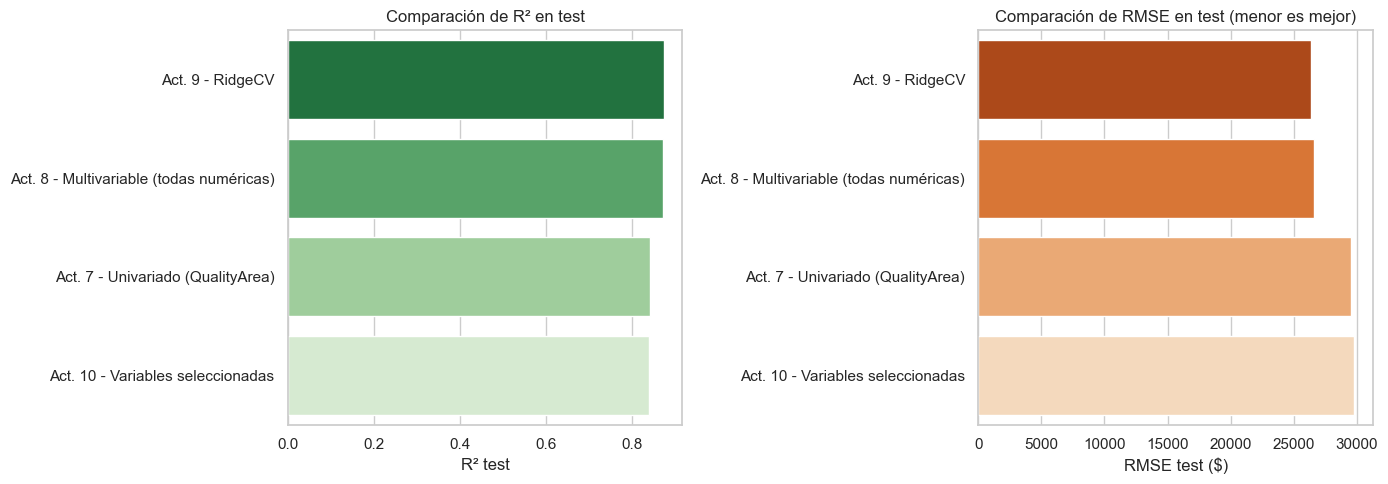

In [31]:
# Actividad 11 — Comparación de eficiencia en test para todos los modelos
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV


def mape(y_true, y_pred):
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    return np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100


# 1) Modelo Act. 7 (univariado)
met_act7 = {
    'Modelo': 'Act. 7 - Univariado (QualityArea)',
    'n_features': 1,
    'R2_test': r2_score(y_test_u, y_pred_u),
    'RMSE_test': np.sqrt(mean_squared_error(y_test_u, y_pred_u)),
    'MAE_test': mean_absolute_error(y_test_u, y_pred_u),
    'MAPE_test (%)': mape(y_test_u, y_pred_u)
}

# 2) Modelo Act. 8 (todas las numéricas)
met_act8 = {
    'Modelo': 'Act. 8 - Multivariable (todas numéricas)',
    'n_features': X_train_m.shape[1],
    'R2_test': r2_score(y_test_m, y_test_pred_m),
    'RMSE_test': np.sqrt(mean_squared_error(y_test_m, y_test_pred_m)),
    'MAE_test': mean_absolute_error(y_test_m, y_test_pred_m),
    'MAPE_test (%)': mape(y_test_m, y_test_pred_m)
}

# 3) Modelo Ridge (A9) entrenado sobre mismas variables de Act. 8
alphas_11 = np.logspace(-3, 3, 40)
ridge_11 = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas_11, cv=5))
])
ridge_11.fit(X_train_m, y_train_m)
y_test_pred_r11 = ridge_11.predict(X_test_m)

met_ridge = {
    'Modelo': 'Act. 9 - RidgeCV',
    'n_features': X_train_m.shape[1],
    'R2_test': r2_score(y_test_m, y_test_pred_r11),
    'RMSE_test': np.sqrt(mean_squared_error(y_test_m, y_test_pred_r11)),
    'MAE_test': mean_absolute_error(y_test_m, y_test_pred_r11),
    'MAPE_test (%)': mape(y_test_m, y_test_pred_r11)
}

# 4) Modelo Act. 10 (variables seleccionadas)
met_act10 = {
    'Modelo': 'Act. 10 - Variables seleccionadas',
    'n_features': p_10,
    'R2_test': r2_score(y_test_10, y_test_pred_10),
    'RMSE_test': np.sqrt(mean_squared_error(y_test_10, y_test_pred_10)),
    'MAE_test': mean_absolute_error(y_test_10, y_test_pred_10),
    'MAPE_test (%)': mape(y_test_10, y_test_pred_10)
}

comparacion_test = pd.DataFrame([met_act7, met_act8, met_ridge, met_act10])
comparacion_test['R2_test'] = comparacion_test['R2_test'].round(4)
comparacion_test['RMSE_test'] = comparacion_test['RMSE_test'].round(2)
comparacion_test['MAE_test'] = comparacion_test['MAE_test'].round(2)
comparacion_test['MAPE_test (%)'] = comparacion_test['MAPE_test (%)'].round(2)

comparacion_test = comparacion_test.sort_values(by='R2_test', ascending=False).reset_index(drop=True)
comparacion_test['Ranking'] = comparacion_test.index + 1

print('=== EFICIENCIA DE MODELOS EN CONJUNTO DE PRUEBA ===')
display(comparacion_test[['Ranking', 'Modelo', 'n_features', 'R2_test', 'RMSE_test', 'MAE_test', 'MAPE_test (%)']])

mejor = comparacion_test.iloc[0]
print(f"Mejor modelo por R2_test: {mejor['Modelo']} (R2_test={mejor['R2_test']:.4f})")

# Visualizaciones comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparacion_test, x='R2_test', y='Modelo', hue='Modelo', palette='Greens_r', legend=False, ax=axes[0])
axes[0].set_title('Comparación de R² en test')
axes[0].set_xlabel('R² test')
axes[0].set_ylabel('')

sns.barplot(data=comparacion_test.sort_values('RMSE_test', ascending=True),
            x='RMSE_test', y='Modelo', hue='Modelo', palette='Oranges_r', legend=False, ax=axes[1])
axes[1].set_title('Comparación de RMSE en test (menor es mejor)')
axes[1].set_xlabel('RMSE test ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### Conclusión de la Actividad 11

Al evaluar todos los modelos sobre el conjunto de prueba con $R^2$, RMSE, MAE y MAPE, se observa que los modelos multivariados superan claramente al modelo univariado en capacidad predictiva.

En términos de precisión global, el mejor desempeño en test corresponde al modelo con mayor $R^2$ y menor error (RMSE/MAE). Esto confirma que incorporar múltiples predictores relevantes mejora la explicación de la variabilidad de `SalePrice` frente a usar un solo predictor.

La comparación también muestra el trade-off entre complejidad y desempeño: el modelo de la Actividad 8 usa más variables y logra mejor precisión, mientras que el de la Actividad 10 mantiene un rendimiento competitivo con menos predictores y menor riesgo de multicolinealidad. Esta evidencia servirá para la selección final del mejor modelo en la Actividad 12.
